# 04 — Black-Scholes Formula, Greeks, and Numerical Checks

This notebook implements the European Black-Scholes-Merton pricing formulas and Greeks under continuous dividend yield.

The previous notebook derived the Black-Scholes PDE from Ito’s lemma, delta hedging, and no-arbitrage logic. This notebook now turns that result into a working benchmark pricing engine and checks whether the formulas behave correctly.

The goal is not to use market data yet. The goal is to make sure the benchmark model is mathematically and numerically sound before using it for Monte Carlo pricing, hedging diagnostics, implied volatility inversion, surface construction, and model-risk analysis.

---

## Central question

Given the Black-Scholes-Merton assumptions, can we compute European call and put prices, compute their Greeks, and verify that the implementation satisfies no-arbitrage identities, finite-difference sensitivity checks, and the Black-Scholes PDE?

---

## Model setting

We use the continuous dividend yield version of Black-Scholes-Merton.

The inputs are:

- `S`: current underlying price
- `K`: strike price
- `tau`: time to maturity, in years
- `r`: continuously compounded risk-free rate
- `q`: continuous dividend yield
- `sigma`: constant volatility

Under the risk-neutral measure, the underlying follows:

$$
dS_t = (r - q)S_t\,dt + \sigma S_t\,dW_t^Q
$$

The Black-Scholes call and put prices are:

$$
C = S e^{-q\tau}N(d_1) - K e^{-r\tau}N(d_2)
$$

$$
P = K e^{-r\tau}N(-d_2) - S e^{-q\tau}N(-d_1)
$$

where:

$$
d_1 =
\frac{
\ln(S/K) + \left(r - q + \frac{1}{2}\sigma^2\right)\tau
}{
\sigma\sqrt{\tau}
}
$$

$$
d_2 = d_1 - \sigma\sqrt{\tau}
$$

The continuous-dividend put-call parity relation is:

$$
C - P = S e^{-q\tau} - K e^{-r\tau}
$$

---

## What this notebook should verify

By the end of the notebook, the implementation should pass the following checks:

1. European call and put prices are finite and economically sensible.
2. Put-call parity holds under continuous dividend yield.
3. Call and put prices obey basic no-arbitrage bounds.
4. Analytic Greeks agree with finite-difference approximations.
5. The implemented formula satisfies the Black-Scholes PDE numerically.
6. Prices behave correctly across strikes, maturities, and volatilities.
7. Near-expiry prices converge toward intrinsic value.
8. The Black-Scholes price is consistent with the binomial convergence logic from Notebook 01.

---

## What this notebook does not prove

This notebook does not claim that real option markets follow Black-Scholes-Merton.

It does not estimate volatility from market data, explain volatility smiles, fit an implied volatility surface, calibrate Heston/Bates models, or validate a trading strategy.

The goal is narrower:

> Build and audit the benchmark pricing engine before moving to Monte Carlo, hedging error, implied volatility, surface construction, and model-risk analysis.

In [1]:
# ============================================================
# 04 — Black-Scholes Formula, Greeks, and Numerical Checks
# Setup, constants, and baseline configuration
# ============================================================

from __future__ import annotations

from dataclasses import dataclass, asdict
from typing import Any, Callable

import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.special import ndtr
from scipy.stats import norm


# -----------------------------
# Notebook display configuration
# -----------------------------

pd.set_option("display.float_format", lambda x: f"{x:,.10f}")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True

warnings.filterwarnings("ignore", category=RuntimeWarning)


# -----------------------------
# Global numerical tolerances
# -----------------------------

PARITY_TOL = 1e-10
BOUNDS_TOL = 1e-10
PDE_RESIDUAL_TOL = 1e-7

FINITE_DIFF_ABS_TOL = {
    "delta": 1e-5,
    "gamma": 1e-4,
    "vega": 1e-4,
    "theta": 1e-4,
    "rho": 1e-4,
}

FINITE_DIFF_REL_TOL = {
    "delta": 1e-4,
    "gamma": 1e-3,
    "vega": 1e-4,
    "theta": 1e-4,
    "rho": 1e-4,
}


# -----------------------------
# Finite-difference bump sizes
# -----------------------------

BUMP_S = 1e-3
BUMP_SIGMA = 1e-5
BUMP_R = 1e-5
BUMP_TAU = 1e-5


# -----------------------------
# Baseline model configuration
# -----------------------------

@dataclass(frozen=True)
class BlackScholesInputs:
    """
    Baseline input container for European Black-Scholes-Merton pricing
    under continuous dividend yield.
    """

    S: float = 100.0
    K: float = 100.0
    tau: float = 1.0
    r: float = 0.05
    q: float = 0.02
    sigma: float = 0.20


BASE = BlackScholesInputs()


# -----------------------------
# Small utility helpers
# -----------------------------

def to_array(x: Any) -> np.ndarray:
    """
    Convert scalar or array-like input to a NumPy array of floats.
    """
    return np.asarray(x, dtype=float)


def standard_normal_cdf(x: Any) -> np.ndarray:
    """
    Standard normal CDF using scipy.special.ndtr.
    """
    return ndtr(x)


def standard_normal_pdf(x: Any) -> np.ndarray:
    """
    Standard normal PDF.
    """
    x = to_array(x)
    return np.exp(-0.5 * x**2) / math.sqrt(2.0 * math.pi)


def max_abs(x: Any) -> float:
    """
    Maximum absolute finite value in an array-like object.
    """
    arr = np.asarray(x, dtype=float)
    return float(np.nanmax(np.abs(arr)))


def audit_row(check: str, metric: float, threshold: float, passed: bool) -> dict[str, Any]:
    """
    Standard row format for final audit tables.
    """
    return {
        "check": check,
        "metric": float(metric),
        "threshold": float(threshold),
        "passed": bool(passed),
    }


print("Notebook 04 setup complete.")
print("Baseline inputs:")
display(pd.DataFrame([asdict(BASE)]))

Notebook 04 setup complete.
Baseline inputs:


,S,K,tau,r,q,sigma
0,100.0000000000,100.0000000000,1.0000000000,0.0500000000,0.0200000000,0.2000000000


In [2]:
# ============================================================
# Black-Scholes-Merton pricing formulas with continuous dividend yield
# ============================================================

def _all_inputs_are_scalar(*values: Any) -> bool:
    """
    Return True only when every input is scalar-like.
    """
    return all(np.ndim(value) == 0 for value in values)


def _broadcast_float_inputs(*values: Any) -> tuple[np.ndarray, ...]:
    """
    Convert inputs to float arrays and broadcast them to a common shape.
    Scalars become 1D arrays with one element, which avoids scalar assignment bugs.
    """
    arrays = [np.atleast_1d(np.asarray(value, dtype=float)) for value in values]
    return tuple(np.broadcast_arrays(*arrays))


def _return_scalar_if_needed(result: np.ndarray, scalar_output: bool) -> float | np.ndarray:
    """
    Return a Python float when all original inputs were scalar; otherwise return an array.
    """
    result = np.asarray(result, dtype=float)
    if scalar_output:
        return float(result.reshape(-1)[0])
    return result


def validate_bsm_inputs(
    S: Any,
    K: Any,
    tau: Any,
    r: Any,
    q: Any,
    sigma: Any,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Validate and broadcast Black-Scholes-Merton inputs.

    Requirements:
    - S > 0
    - K > 0
    - tau >= 0
    - sigma >= 0
    - all inputs finite
    """
    S_arr, K_arr, tau_arr, r_arr, q_arr, sigma_arr = _broadcast_float_inputs(
        S, K, tau, r, q, sigma
    )

    arrays = {
        "S": S_arr,
        "K": K_arr,
        "tau": tau_arr,
        "r": r_arr,
        "q": q_arr,
        "sigma": sigma_arr,
    }

    for name, arr in arrays.items():
        if not np.all(np.isfinite(arr)):
            raise ValueError(f"{name} contains non-finite values.")

    if np.any(S_arr <= 0):
        raise ValueError("Underlying price S must be strictly positive.")

    if np.any(K_arr <= 0):
        raise ValueError("Strike K must be strictly positive.")

    if np.any(tau_arr < 0):
        raise ValueError("Time to maturity tau must be nonnegative.")

    if np.any(sigma_arr < 0):
        raise ValueError("Volatility sigma must be nonnegative.")

    return S_arr, K_arr, tau_arr, r_arr, q_arr, sigma_arr


def deterministic_call_value(
    S: Any,
    K: Any,
    tau: Any,
    r: Any,
    q: Any,
) -> float | np.ndarray:
    """
    Black-Scholes-Merton limiting call value when tau = 0 or sigma = 0.

    For tau > 0 and sigma = 0, the risk-neutral terminal stock price is deterministic.
    The discounted payoff becomes:

        max(S exp(-q tau) - K exp(-r tau), 0)

    For tau = 0, this reduces to intrinsic value.
    """
    scalar_output = _all_inputs_are_scalar(S, K, tau, r, q)
    S_arr, K_arr, tau_arr, r_arr, q_arr = _broadcast_float_inputs(S, K, tau, r, q)

    value = np.maximum(
        S_arr * np.exp(-q_arr * tau_arr) - K_arr * np.exp(-r_arr * tau_arr),
        0.0,
    )

    return _return_scalar_if_needed(value, scalar_output)


def deterministic_put_value(
    S: Any,
    K: Any,
    tau: Any,
    r: Any,
    q: Any,
) -> float | np.ndarray:
    """
    Black-Scholes-Merton limiting put value when tau = 0 or sigma = 0.

    For tau > 0 and sigma = 0, the risk-neutral terminal stock price is deterministic.
    The discounted payoff becomes:

        max(K exp(-r tau) - S exp(-q tau), 0)

    For tau = 0, this reduces to intrinsic value.
    """
    scalar_output = _all_inputs_are_scalar(S, K, tau, r, q)
    S_arr, K_arr, tau_arr, r_arr, q_arr = _broadcast_float_inputs(S, K, tau, r, q)

    value = np.maximum(
        K_arr * np.exp(-r_arr * tau_arr) - S_arr * np.exp(-q_arr * tau_arr),
        0.0,
    )

    return _return_scalar_if_needed(value, scalar_output)


def bsm_d1_d2(
    S: Any,
    K: Any,
    tau: Any,
    r: Any,
    q: Any,
    sigma: Any,
) -> tuple[float | np.ndarray, float | np.ndarray]:
    """
    Compute d1 and d2 for the continuous-dividend Black-Scholes-Merton model.

    This function is defined only for tau > 0 and sigma > 0.
    Degenerate cases are handled directly in the price functions.
    """
    scalar_output = _all_inputs_are_scalar(S, K, tau, r, q, sigma)
    S_arr, K_arr, tau_arr, r_arr, q_arr, sigma_arr = validate_bsm_inputs(
        S, K, tau, r, q, sigma
    )

    if np.any(tau_arr <= 0):
        raise ValueError("d1 and d2 require tau > 0.")

    if np.any(sigma_arr <= 0):
        raise ValueError("d1 and d2 require sigma > 0.")

    sqrt_tau = np.sqrt(tau_arr)

    d1 = (
        np.log(S_arr / K_arr)
        + (r_arr - q_arr + 0.5 * sigma_arr**2) * tau_arr
    ) / (sigma_arr * sqrt_tau)

    d2 = d1 - sigma_arr * sqrt_tau

    return (
        _return_scalar_if_needed(d1, scalar_output),
        _return_scalar_if_needed(d2, scalar_output),
    )


def bsm_call_price(
    S: Any,
    K: Any,
    tau: Any,
    r: Any,
    q: Any,
    sigma: Any,
) -> float | np.ndarray:
    """
    European call price under Black-Scholes-Merton with continuous dividend yield.
    Handles tau = 0 and sigma = 0 explicitly.
    """
    scalar_output = _all_inputs_are_scalar(S, K, tau, r, q, sigma)
    S_arr, K_arr, tau_arr, r_arr, q_arr, sigma_arr = validate_bsm_inputs(
        S, K, tau, r, q, sigma
    )

    deterministic = deterministic_call_value(S_arr, K_arr, tau_arr, r_arr, q_arr)

    active = (tau_arr > 0) & (sigma_arr > 0)
    call = np.asarray(deterministic, dtype=float).copy()

    if np.any(active):
        d1, d2 = bsm_d1_d2(
            S_arr[active],
            K_arr[active],
            tau_arr[active],
            r_arr[active],
            q_arr[active],
            sigma_arr[active],
        )

        call[active] = (
            S_arr[active]
            * np.exp(-q_arr[active] * tau_arr[active])
            * standard_normal_cdf(d1)
            - K_arr[active]
            * np.exp(-r_arr[active] * tau_arr[active])
            * standard_normal_cdf(d2)
        )

    return _return_scalar_if_needed(call, scalar_output)


def bsm_put_price(
    S: Any,
    K: Any,
    tau: Any,
    r: Any,
    q: Any,
    sigma: Any,
) -> float | np.ndarray:
    """
    European put price under Black-Scholes-Merton with continuous dividend yield.
    Handles tau = 0 and sigma = 0 explicitly.
    """
    scalar_output = _all_inputs_are_scalar(S, K, tau, r, q, sigma)
    S_arr, K_arr, tau_arr, r_arr, q_arr, sigma_arr = validate_bsm_inputs(
        S, K, tau, r, q, sigma
    )

    deterministic = deterministic_put_value(S_arr, K_arr, tau_arr, r_arr, q_arr)

    active = (tau_arr > 0) & (sigma_arr > 0)
    put = np.asarray(deterministic, dtype=float).copy()

    if np.any(active):
        d1, d2 = bsm_d1_d2(
            S_arr[active],
            K_arr[active],
            tau_arr[active],
            r_arr[active],
            q_arr[active],
            sigma_arr[active],
        )

        put[active] = (
            K_arr[active]
            * np.exp(-r_arr[active] * tau_arr[active])
            * standard_normal_cdf(-d2)
            - S_arr[active]
            * np.exp(-q_arr[active] * tau_arr[active])
            * standard_normal_cdf(-d1)
        )

    return _return_scalar_if_needed(put, scalar_output)


# -----------------------------
# Baseline pricing sanity check
# -----------------------------

base_d1, base_d2 = bsm_d1_d2(BASE.S, BASE.K, BASE.tau, BASE.r, BASE.q, BASE.sigma)
base_call = bsm_call_price(BASE.S, BASE.K, BASE.tau, BASE.r, BASE.q, BASE.sigma)
base_put = bsm_put_price(BASE.S, BASE.K, BASE.tau, BASE.r, BASE.q, BASE.sigma)

discount_factor = math.exp(-BASE.r * BASE.tau)
dividend_discount = math.exp(-BASE.q * BASE.tau)
forward_price = BASE.S * math.exp((BASE.r - BASE.q) * BASE.tau)

baseline_pricing_summary = pd.DataFrame(
    [
        {
            "S": BASE.S,
            "K": BASE.K,
            "tau": BASE.tau,
            "r": BASE.r,
            "q": BASE.q,
            "sigma": BASE.sigma,
            "discount_factor": discount_factor,
            "dividend_discount": dividend_discount,
            "forward_price": forward_price,
            "d1": base_d1,
            "d2": base_d2,
            "call_price": base_call,
            "put_price": base_put,
        }
    ]
)

print("Baseline Black-Scholes-Merton pricing summary:")
display(baseline_pricing_summary)

Baseline Black-Scholes-Merton pricing summary:


,S,K,tau,r,q,sigma,discount_factor,dividend_discount,forward_price,d1,d2,call_price,put_price
0,100.0000000000,100.0000000000,1.0000000000,0.0500000000,0.0200000000,0.2000000000,0.9512294245,0.9801986733,103.0454533954,0.2500000000,0.0500000000,9.2270055082,6.3300806275


In [3]:
# ============================================================
# Put-call parity and no-arbitrage bound checks
# ============================================================

from itertools import product


def build_bsm_test_grid() -> pd.DataFrame:
    """
    Build a broad but controlled parameter grid for Black-Scholes-Merton
    identity and no-arbitrage checks.

    Includes tau = 0 and sigma = 0 to verify degenerate-case handling.
    """
    grid_values = {
        "S": [60.0, 80.0, 100.0, 120.0, 140.0],
        "K": [70.0, 90.0, 100.0, 110.0, 130.0],
        "tau": [0.0, 1.0 / 252.0, 0.25, 1.0, 2.0],
        "r": [-0.01, 0.00, 0.05],
        "q": [0.00, 0.02, 0.04],
        "sigma": [0.0, 0.05, 0.20, 0.60],
    }

    rows = [
        dict(zip(grid_values.keys(), values))
        for values in product(*grid_values.values())
    ]

    return pd.DataFrame(rows)


def put_call_parity_residual(
    S: Any,
    K: Any,
    tau: Any,
    r: Any,
    q: Any,
    sigma: Any,
) -> float | np.ndarray:
    """
    Continuous-dividend put-call parity residual:

        (C - P) - (S exp(-q tau) - K exp(-r tau))

    A correct implementation should produce residuals near zero.
    """
    S_arr, K_arr, tau_arr, r_arr, q_arr, sigma_arr = validate_bsm_inputs(
        S, K, tau, r, q, sigma
    )

    call = bsm_call_price(S_arr, K_arr, tau_arr, r_arr, q_arr, sigma_arr)
    put = bsm_put_price(S_arr, K_arr, tau_arr, r_arr, q_arr, sigma_arr)

    parity_rhs = (
        S_arr * np.exp(-q_arr * tau_arr)
        - K_arr * np.exp(-r_arr * tau_arr)
    )

    residual = call - put - parity_rhs

    scalar_output = _all_inputs_are_scalar(S, K, tau, r, q, sigma)
    return _return_scalar_if_needed(residual, scalar_output)


def no_arbitrage_bound_violations(
    S: Any,
    K: Any,
    tau: Any,
    r: Any,
    q: Any,
    sigma: Any,
) -> pd.DataFrame:
    """
    Compute no-arbitrage bound violations for European calls and puts
    under continuous dividend yield.

    Call bounds:

        max(S exp(-q tau) - K exp(-r tau), 0) <= C <= S exp(-q tau)

    Put bounds:

        max(K exp(-r tau) - S exp(-q tau), 0) <= P <= K exp(-r tau)
    """
    S_arr, K_arr, tau_arr, r_arr, q_arr, sigma_arr = validate_bsm_inputs(
        S, K, tau, r, q, sigma
    )

    call = bsm_call_price(S_arr, K_arr, tau_arr, r_arr, q_arr, sigma_arr)
    put = bsm_put_price(S_arr, K_arr, tau_arr, r_arr, q_arr, sigma_arr)

    discounted_spot = S_arr * np.exp(-q_arr * tau_arr)
    discounted_strike = K_arr * np.exp(-r_arr * tau_arr)

    call_lower = np.maximum(discounted_spot - discounted_strike, 0.0)
    call_upper = discounted_spot

    put_lower = np.maximum(discounted_strike - discounted_spot, 0.0)
    put_upper = discounted_strike

    violations = pd.DataFrame(
        {
            "call_lower_violation": np.maximum(call_lower - call, 0.0),
            "call_upper_violation": np.maximum(call - call_upper, 0.0),
            "put_lower_violation": np.maximum(put_lower - put, 0.0),
            "put_upper_violation": np.maximum(put - put_upper, 0.0),
        }
    )

    return violations


# -----------------------------
# Run parity and bounds audit
# -----------------------------

bsm_test_grid = build_bsm_test_grid()

grid_call = bsm_call_price(
    bsm_test_grid["S"].to_numpy(),
    bsm_test_grid["K"].to_numpy(),
    bsm_test_grid["tau"].to_numpy(),
    bsm_test_grid["r"].to_numpy(),
    bsm_test_grid["q"].to_numpy(),
    bsm_test_grid["sigma"].to_numpy(),
)

grid_put = bsm_put_price(
    bsm_test_grid["S"].to_numpy(),
    bsm_test_grid["K"].to_numpy(),
    bsm_test_grid["tau"].to_numpy(),
    bsm_test_grid["r"].to_numpy(),
    bsm_test_grid["q"].to_numpy(),
    bsm_test_grid["sigma"].to_numpy(),
)

grid_parity_residual = put_call_parity_residual(
    bsm_test_grid["S"].to_numpy(),
    bsm_test_grid["K"].to_numpy(),
    bsm_test_grid["tau"].to_numpy(),
    bsm_test_grid["r"].to_numpy(),
    bsm_test_grid["q"].to_numpy(),
    bsm_test_grid["sigma"].to_numpy(),
)

grid_bound_violations = no_arbitrage_bound_violations(
    bsm_test_grid["S"].to_numpy(),
    bsm_test_grid["K"].to_numpy(),
    bsm_test_grid["tau"].to_numpy(),
    bsm_test_grid["r"].to_numpy(),
    bsm_test_grid["q"].to_numpy(),
    bsm_test_grid["sigma"].to_numpy(),
)

bsm_test_results = bsm_test_grid.copy()
bsm_test_results["call_price"] = grid_call
bsm_test_results["put_price"] = grid_put
bsm_test_results["parity_residual"] = grid_parity_residual

for col in grid_bound_violations.columns:
    bsm_test_results[col] = grid_bound_violations[col].to_numpy()


max_parity_residual = max_abs(bsm_test_results["parity_residual"])

bound_audit_summary = pd.DataFrame(
    [
        {
            "check": "put_call_parity",
            "max_violation": max_parity_residual,
            "threshold": PARITY_TOL,
            "passed": max_parity_residual <= PARITY_TOL,
        },
        {
            "check": "call_lower_bound",
            "max_violation": float(bsm_test_results["call_lower_violation"].max()),
            "threshold": BOUNDS_TOL,
            "passed": float(bsm_test_results["call_lower_violation"].max()) <= BOUNDS_TOL,
        },
        {
            "check": "call_upper_bound",
            "max_violation": float(bsm_test_results["call_upper_violation"].max()),
            "threshold": BOUNDS_TOL,
            "passed": float(bsm_test_results["call_upper_violation"].max()) <= BOUNDS_TOL,
        },
        {
            "check": "put_lower_bound",
            "max_violation": float(bsm_test_results["put_lower_violation"].max()),
            "threshold": BOUNDS_TOL,
            "passed": float(bsm_test_results["put_lower_violation"].max()) <= BOUNDS_TOL,
        },
        {
            "check": "put_upper_bound",
            "max_violation": float(bsm_test_results["put_upper_violation"].max()),
            "threshold": BOUNDS_TOL,
            "passed": float(bsm_test_results["put_upper_violation"].max()) <= BOUNDS_TOL,
        },
    ]
)

worst_parity_cases = (
    bsm_test_results.assign(abs_parity_residual=lambda df: df["parity_residual"].abs())
    .sort_values("abs_parity_residual", ascending=False)
    .head(10)
    [
        [
            "S",
            "K",
            "tau",
            "r",
            "q",
            "sigma",
            "call_price",
            "put_price",
            "parity_residual",
            "abs_parity_residual",
        ]
    ]
)

print(f"Parameter grid rows checked: {len(bsm_test_results):,}")
print("Put-call parity and no-arbitrage bound audit:")
display(bound_audit_summary)

print("Worst put-call parity residual cases:")
display(worst_parity_cases)

if not bool(bound_audit_summary["passed"].all()):
    raise AssertionError("Put-call parity or no-arbitrage bound audit failed.")

Parameter grid rows checked: 4,500
Put-call parity and no-arbitrage bound audit:


,check,max_violation,threshold,passed
0,put_call_parity,0.0000000000,0.0000000001,True
1,call_lower_bound,0.0000000000,0.0000000001,True
2,call_upper_bound,0.0000000000,0.0000000001,True
3,put_lower_bound,0.0000000000,0.0000000001,True
4,put_upper_bound,0.0000000000,0.0000000001,True


Worst put-call parity residual cases:


,S,K,tau,r,q,sigma,call_price,put_price,parity_residual,abs_parity_residual
883,60.0000000000,130.0000000000,2.0000000000,0.0000000000,0.0200000000,0.6000000000,6.2596646491,78.6122982999,0.0000000000,0.0000000000
842,60.0000000000,130.0000000000,1.0000000000,0.0000000000,0.0000000000,0.2000000000,0.0002257377,70.0002257377,0.0000000000,0.0000000000
3726,140.0000000000,70.0000000000,1.0000000000,0.0000000000,0.0200000000,0.2000000000,67.2297454436,0.0019311806,0.0000000000,0.0000000000
834,60.0000000000,130.0000000000,1.0000000000,-0.0100000000,0.0200000000,0.2000000000,0.0001164644,72.4947177870,0.0000000000,0.0000000000
806,60.0000000000,130.0000000000,0.2500000000,0.0000000000,0.0000000000,0.2000000000,0.0000000000,70.0000000000,-0.0000000000,0.0000000000
4370,140.0000000000,130.0000000000,0.0039682540,0.0000000000,0.0000000000,0.2000000000,10.0000000006,0.0000000006,0.0000000000,0.0000000000
4401,140.0000000000,130.0000000000,0.2500000000,-0.0100000000,0.0400000000,0.0500000000,8.2890867800,0.0075166438,0.0000000000,0.0000000000
2606,100.0000000000,130.0000000000,0.2500000000,0.0000000000,0.0000000000,0.2000000000,0.0154604406,30.0154604406,0.0000000000,0.0000000000
3569,120.0000000000,130.0000000000,2.0000000000,-0.0100000000,0.0200000000,0.0500000000,0.0781727326,17.4096142378,-0.0000000000,0.0000000000
4269,140.0000000000,110.0000000000,1.0000000000,0.0000000000,0.0400000000,0.0500000000,24.5105606638,0.0000391825,0.0000000000,0.0000000000


## 3. Greeks: sensitivity formulas and interpretation

The previous section verified that the Black-Scholes-Merton call and put prices satisfy put-call parity and basic no-arbitrage bounds. The next step is to compute the Greeks.

Greeks measure how the option value changes when one model input changes while the others are held fixed.

For a European option price \(V(S, K, \tau, r, q, \sigma)\), the main Greeks are:

| Greek | Meaning | Variable bumped |
|---|---|---|
| Delta | sensitivity to the underlying price | \(S\) |
| Gamma | curvature with respect to the underlying price | \(S\) twice |
| Vega | sensitivity to volatility | \(\sigma\) |
| Theta | sensitivity to calendar time passing | \(t\) |
| Rho | sensitivity to the risk-free rate | \(r\) |

Theta needs special care because the implementation uses time to maturity \(\tau\), while market convention usually defines theta with respect to calendar time \(t\).

Since:

$$
\tau = T - t
$$

we have:

$$
\frac{\partial V}{\partial t}
=
-\frac{\partial V}{\partial \tau}
$$

So in this notebook:

$$
\Theta = \frac{\partial V}{\partial t}
$$

not:

$$
\frac{\partial V}{\partial \tau}
$$

That sign convention matters when checking theta numerically.

---

### Continuous-dividend Black-Scholes Greeks

For the call option:

$$
\Delta_C = e^{-q\tau}N(d_1)
$$

For the put option:

$$
\Delta_P = e^{-q\tau}\left(N(d_1) - 1\right)
$$

Gamma is the same for calls and puts:

$$
\Gamma =
\frac{
e^{-q\tau}\phi(d_1)
}{
S\sigma\sqrt{\tau}
}
$$

Vega is also the same for calls and puts:

$$
\nu =
S e^{-q\tau}\phi(d_1)\sqrt{\tau}
$$

where \(\phi(\cdot)\) is the standard normal density.

Call theta is:

$$
\Theta_C =
-\frac{
S e^{-q\tau}\phi(d_1)\sigma
}{
2\sqrt{\tau}
}
+
qS e^{-q\tau}N(d_1)
-
rK e^{-r\tau}N(d_2)
$$

Put theta is:

$$
\Theta_P =
-\frac{
S e^{-q\tau}\phi(d_1)\sigma
}{
2\sqrt{\tau}
}
-
qS e^{-q\tau}N(-d_1)
+
rK e^{-r\tau}N(-d_2)
$$

Call rho is:

$$
\rho_C =
K\tau e^{-r\tau}N(d_2)
$$

Put rho is:

$$
\rho_P =
-K\tau e^{-r\tau}N(-d_2)
$$

All Greeks in this notebook are reported in raw mathematical units:

- Vega is per \(1.00\) change in volatility, not per one volatility point.
- Theta is per year.
- Rho is per \(1.00\) change in the continuously compounded risk-free rate.

In [4]:
# ============================================================
# Black-Scholes-Merton Greeks with continuous dividend yield
# ============================================================

def _empty_like_bsm_input(
    S: Any,
    K: Any,
    tau: Any,
    r: Any,
    q: Any,
    sigma: Any,
    fill_value: float = np.nan,
) -> tuple[
    np.ndarray,
    np.ndarray,
    np.ndarray,
    np.ndarray,
    np.ndarray,
    np.ndarray,
    np.ndarray,
    bool,
]:
    """
    Validate BSM inputs, broadcast them, and create an output array
    with the same broadcast shape.

    Degenerate Greek cases such as tau = 0 or sigma = 0 are left as NaN
    unless explicitly handled by a specific Greek function.
    """
    scalar_output = _all_inputs_are_scalar(S, K, tau, r, q, sigma)
    S_arr, K_arr, tau_arr, r_arr, q_arr, sigma_arr = validate_bsm_inputs(
        S, K, tau, r, q, sigma
    )

    out = np.full_like(S_arr, fill_value, dtype=float)

    return S_arr, K_arr, tau_arr, r_arr, q_arr, sigma_arr, out, scalar_output


def bsm_call_delta(
    S: Any,
    K: Any,
    tau: Any,
    r: Any,
    q: Any,
    sigma: Any,
) -> float | np.ndarray:
    """
    Black-Scholes-Merton call delta under continuous dividend yield.

        Delta_C = exp(-q tau) N(d1)

    For tau = 0 or sigma = 0, delta is discontinuous at the strike,
    so this implementation returns NaN for degenerate cases.
    """
    S_arr, K_arr, tau_arr, r_arr, q_arr, sigma_arr, delta, scalar_output = (
        _empty_like_bsm_input(S, K, tau, r, q, sigma)
    )

    active = (tau_arr > 0) & (sigma_arr > 0)

    if np.any(active):
        d1, _ = bsm_d1_d2(
            S_arr[active],
            K_arr[active],
            tau_arr[active],
            r_arr[active],
            q_arr[active],
            sigma_arr[active],
        )

        delta[active] = np.exp(-q_arr[active] * tau_arr[active]) * standard_normal_cdf(d1)

    return _return_scalar_if_needed(delta, scalar_output)


def bsm_put_delta(
    S: Any,
    K: Any,
    tau: Any,
    r: Any,
    q: Any,
    sigma: Any,
) -> float | np.ndarray:
    """
    Black-Scholes-Merton put delta under continuous dividend yield.

        Delta_P = exp(-q tau) [N(d1) - 1]

    For tau = 0 or sigma = 0, delta is discontinuous at the strike,
    so this implementation returns NaN for degenerate cases.
    """
    S_arr, K_arr, tau_arr, r_arr, q_arr, sigma_arr, delta, scalar_output = (
        _empty_like_bsm_input(S, K, tau, r, q, sigma)
    )

    active = (tau_arr > 0) & (sigma_arr > 0)

    if np.any(active):
        d1, _ = bsm_d1_d2(
            S_arr[active],
            K_arr[active],
            tau_arr[active],
            r_arr[active],
            q_arr[active],
            sigma_arr[active],
        )

        delta[active] = (
            np.exp(-q_arr[active] * tau_arr[active])
            * (standard_normal_cdf(d1) - 1.0)
        )

    return _return_scalar_if_needed(delta, scalar_output)


def bsm_gamma(
    S: Any,
    K: Any,
    tau: Any,
    r: Any,
    q: Any,
    sigma: Any,
) -> float | np.ndarray:
    """
    Black-Scholes-Merton gamma under continuous dividend yield.

    Gamma is the same for calls and puts:

        Gamma = exp(-q tau) phi(d1) / [S sigma sqrt(tau)]
    """
    S_arr, K_arr, tau_arr, r_arr, q_arr, sigma_arr, gamma, scalar_output = (
        _empty_like_bsm_input(S, K, tau, r, q, sigma)
    )

    active = (tau_arr > 0) & (sigma_arr > 0)

    if np.any(active):
        d1, _ = bsm_d1_d2(
            S_arr[active],
            K_arr[active],
            tau_arr[active],
            r_arr[active],
            q_arr[active],
            sigma_arr[active],
        )

        gamma[active] = (
            np.exp(-q_arr[active] * tau_arr[active])
            * standard_normal_pdf(d1)
            / (S_arr[active] * sigma_arr[active] * np.sqrt(tau_arr[active]))
        )

    return _return_scalar_if_needed(gamma, scalar_output)


def bsm_vega(
    S: Any,
    K: Any,
    tau: Any,
    r: Any,
    q: Any,
    sigma: Any,
) -> float | np.ndarray:
    """
    Black-Scholes-Merton vega under continuous dividend yield.

    Vega is the same for calls and puts:

        Vega = S exp(-q tau) phi(d1) sqrt(tau)

    Units: price change per 1.00 change in volatility.
    Divide by 100 to express per one volatility point.
    """
    S_arr, K_arr, tau_arr, r_arr, q_arr, sigma_arr, vega, scalar_output = (
        _empty_like_bsm_input(S, K, tau, r, q, sigma)
    )

    active = (tau_arr > 0) & (sigma_arr > 0)

    if np.any(active):
        d1, _ = bsm_d1_d2(
            S_arr[active],
            K_arr[active],
            tau_arr[active],
            r_arr[active],
            q_arr[active],
            sigma_arr[active],
        )

        vega[active] = (
            S_arr[active]
            * np.exp(-q_arr[active] * tau_arr[active])
            * standard_normal_pdf(d1)
            * np.sqrt(tau_arr[active])
        )

    return _return_scalar_if_needed(vega, scalar_output)


def bsm_call_theta(
    S: Any,
    K: Any,
    tau: Any,
    r: Any,
    q: Any,
    sigma: Any,
) -> float | np.ndarray:
    """
    Black-Scholes-Merton call theta under continuous dividend yield.

    Theta is defined as calendar-time sensitivity:

        Theta = dV/dt

    Since tau = T - t, theta is not dV/dtau. It is the negative of
    the time-to-maturity derivative.
    """
    S_arr, K_arr, tau_arr, r_arr, q_arr, sigma_arr, theta, scalar_output = (
        _empty_like_bsm_input(S, K, tau, r, q, sigma)
    )

    active = (tau_arr > 0) & (sigma_arr > 0)

    if np.any(active):
        d1, d2 = bsm_d1_d2(
            S_arr[active],
            K_arr[active],
            tau_arr[active],
            r_arr[active],
            q_arr[active],
            sigma_arr[active],
        )

        first_term = (
            -S_arr[active]
            * np.exp(-q_arr[active] * tau_arr[active])
            * standard_normal_pdf(d1)
            * sigma_arr[active]
            / (2.0 * np.sqrt(tau_arr[active]))
        )

        carry_term = (
            q_arr[active]
            * S_arr[active]
            * np.exp(-q_arr[active] * tau_arr[active])
            * standard_normal_cdf(d1)
        )

        discount_term = (
            -r_arr[active]
            * K_arr[active]
            * np.exp(-r_arr[active] * tau_arr[active])
            * standard_normal_cdf(d2)
        )

        theta[active] = first_term + carry_term + discount_term

    return _return_scalar_if_needed(theta, scalar_output)


def bsm_put_theta(
    S: Any,
    K: Any,
    tau: Any,
    r: Any,
    q: Any,
    sigma: Any,
) -> float | np.ndarray:
    """
    Black-Scholes-Merton put theta under continuous dividend yield.

    Theta is defined as calendar-time sensitivity:

        Theta = dV/dt

    Units: price change per year.
    """
    S_arr, K_arr, tau_arr, r_arr, q_arr, sigma_arr, theta, scalar_output = (
        _empty_like_bsm_input(S, K, tau, r, q, sigma)
    )

    active = (tau_arr > 0) & (sigma_arr > 0)

    if np.any(active):
        d1, d2 = bsm_d1_d2(
            S_arr[active],
            K_arr[active],
            tau_arr[active],
            r_arr[active],
            q_arr[active],
            sigma_arr[active],
        )

        first_term = (
            -S_arr[active]
            * np.exp(-q_arr[active] * tau_arr[active])
            * standard_normal_pdf(d1)
            * sigma_arr[active]
            / (2.0 * np.sqrt(tau_arr[active]))
        )

        carry_term = (
            -q_arr[active]
            * S_arr[active]
            * np.exp(-q_arr[active] * tau_arr[active])
            * standard_normal_cdf(-d1)
        )

        discount_term = (
            r_arr[active]
            * K_arr[active]
            * np.exp(-r_arr[active] * tau_arr[active])
            * standard_normal_cdf(-d2)
        )

        theta[active] = first_term + carry_term + discount_term

    return _return_scalar_if_needed(theta, scalar_output)


def bsm_call_rho(
    S: Any,
    K: Any,
    tau: Any,
    r: Any,
    q: Any,
    sigma: Any,
) -> float | np.ndarray:
    """
    Black-Scholes-Merton call rho under continuous dividend yield.

        Rho_C = K tau exp(-r tau) N(d2)

    Units: price change per 1.00 change in r.
    """
    S_arr, K_arr, tau_arr, r_arr, q_arr, sigma_arr, rho, scalar_output = (
        _empty_like_bsm_input(S, K, tau, r, q, sigma)
    )

    active = (tau_arr > 0) & (sigma_arr > 0)

    if np.any(active):
        _, d2 = bsm_d1_d2(
            S_arr[active],
            K_arr[active],
            tau_arr[active],
            r_arr[active],
            q_arr[active],
            sigma_arr[active],
        )

        rho[active] = (
            K_arr[active]
            * tau_arr[active]
            * np.exp(-r_arr[active] * tau_arr[active])
            * standard_normal_cdf(d2)
        )

    return _return_scalar_if_needed(rho, scalar_output)


def bsm_put_rho(
    S: Any,
    K: Any,
    tau: Any,
    r: Any,
    q: Any,
    sigma: Any,
) -> float | np.ndarray:
    """
    Black-Scholes-Merton put rho under continuous dividend yield.

        Rho_P = -K tau exp(-r tau) N(-d2)

    Units: price change per 1.00 change in r.
    """
    S_arr, K_arr, tau_arr, r_arr, q_arr, sigma_arr, rho, scalar_output = (
        _empty_like_bsm_input(S, K, tau, r, q, sigma)
    )

    active = (tau_arr > 0) & (sigma_arr > 0)

    if np.any(active):
        _, d2 = bsm_d1_d2(
            S_arr[active],
            K_arr[active],
            tau_arr[active],
            r_arr[active],
            q_arr[active],
            sigma_arr[active],
        )

        rho[active] = (
            -K_arr[active]
            * tau_arr[active]
            * np.exp(-r_arr[active] * tau_arr[active])
            * standard_normal_cdf(-d2)
        )

    return _return_scalar_if_needed(rho, scalar_output)


# -----------------------------
# Baseline Greeks table
# -----------------------------

baseline_greeks = pd.DataFrame(
    [
        {
            "call_price": bsm_call_price(BASE.S, BASE.K, BASE.tau, BASE.r, BASE.q, BASE.sigma),
            "put_price": bsm_put_price(BASE.S, BASE.K, BASE.tau, BASE.r, BASE.q, BASE.sigma),
            "call_delta": bsm_call_delta(BASE.S, BASE.K, BASE.tau, BASE.r, BASE.q, BASE.sigma),
            "put_delta": bsm_put_delta(BASE.S, BASE.K, BASE.tau, BASE.r, BASE.q, BASE.sigma),
            "gamma": bsm_gamma(BASE.S, BASE.K, BASE.tau, BASE.r, BASE.q, BASE.sigma),
            "vega_raw": bsm_vega(BASE.S, BASE.K, BASE.tau, BASE.r, BASE.q, BASE.sigma),
            "vega_per_vol_point": bsm_vega(BASE.S, BASE.K, BASE.tau, BASE.r, BASE.q, BASE.sigma) / 100.0,
            "call_theta_per_year": bsm_call_theta(BASE.S, BASE.K, BASE.tau, BASE.r, BASE.q, BASE.sigma),
            "put_theta_per_year": bsm_put_theta(BASE.S, BASE.K, BASE.tau, BASE.r, BASE.q, BASE.sigma),
            "call_rho_raw": bsm_call_rho(BASE.S, BASE.K, BASE.tau, BASE.r, BASE.q, BASE.sigma),
            "put_rho_raw": bsm_put_rho(BASE.S, BASE.K, BASE.tau, BASE.r, BASE.q, BASE.sigma),
            "call_rho_per_1bp": bsm_call_rho(BASE.S, BASE.K, BASE.tau, BASE.r, BASE.q, BASE.sigma) / 10_000.0,
            "put_rho_per_1bp": bsm_put_rho(BASE.S, BASE.K, BASE.tau, BASE.r, BASE.q, BASE.sigma) / 10_000.0,
        }
    ]
)

print("Baseline Black-Scholes-Merton Greeks:")
display(baseline_greeks)

Baseline Black-Scholes-Merton Greeks:


,call_price,put_price,call_delta,put_delta,gamma,vega_raw,vega_per_vol_point,call_theta_per_year,put_theta_per_year,call_rho_raw,put_rho_raw,call_rho_per_1bp,put_rho_per_1bp
0,9.2270055082,6.3300806275,0.5868511461,-0.3933475272,0.0189505788,37.9011575100,0.3790115751,-5.0893189140,-2.2935691381,49.4581091053,-45.6648333447,0.0049458109,-0.0045664833


In [5]:
# ============================================================
# Finite-difference checks for Greeks
# ============================================================

def relative_error(analytic: float, numerical: float, floor: float = 1e-12) -> float:
    """
    Stable relative error using the analytic value as reference.
    """
    denom = max(abs(float(analytic)), floor)
    return abs(float(analytic) - float(numerical)) / denom


def central_difference_first(
    func: Callable[[float], float],
    x: float,
    h: float,
) -> float:
    """
    Central first derivative approximation.
    """
    return (func(x + h) - func(x - h)) / (2.0 * h)


def central_difference_second(
    func: Callable[[float], float],
    x: float,
    h: float,
) -> float:
    """
    Central second derivative approximation.
    """
    return (func(x + h) - 2.0 * func(x) + func(x - h)) / (h**2)


def finite_diff_delta(price_func: Callable[..., float], params: BlackScholesInputs) -> float:
    """
    Finite-difference delta by bumping S.
    """
    if params.S - BUMP_S <= 0:
        raise ValueError("S bump would make S nonpositive.")

    return central_difference_first(
        lambda S_: price_func(S_, params.K, params.tau, params.r, params.q, params.sigma),
        params.S,
        BUMP_S,
    )


def finite_diff_gamma(price_func: Callable[..., float], params: BlackScholesInputs) -> float:
    """
    Finite-difference gamma by bumping S twice.
    """
    if params.S - BUMP_S <= 0:
        raise ValueError("S bump would make S nonpositive.")

    return central_difference_second(
        lambda S_: price_func(S_, params.K, params.tau, params.r, params.q, params.sigma),
        params.S,
        BUMP_S,
    )


def finite_diff_vega(price_func: Callable[..., float], params: BlackScholesInputs) -> float:
    """
    Finite-difference vega by bumping sigma.

    Units match analytic vega: price change per 1.00 change in volatility.
    """
    if params.sigma - BUMP_SIGMA <= 0:
        raise ValueError("Sigma bump would make sigma nonpositive.")

    return central_difference_first(
        lambda sigma_: price_func(params.S, params.K, params.tau, params.r, params.q, sigma_),
        params.sigma,
        BUMP_SIGMA,
    )


def finite_diff_theta(price_func: Callable[..., float], params: BlackScholesInputs) -> float:
    """
    Finite-difference theta.

    The implementation uses tau = T - t.

    Analytic theta convention is:

        theta = dV/dt

    Therefore:

        theta = -dV/dtau

    The finite-difference check must include this negative sign.
    """
    if params.tau - BUMP_TAU <= 0:
        raise ValueError("Tau bump would make tau nonpositive.")

    d_price_d_tau = central_difference_first(
        lambda tau_: price_func(params.S, params.K, tau_, params.r, params.q, params.sigma),
        params.tau,
        BUMP_TAU,
    )

    return -d_price_d_tau


def finite_diff_rho(price_func: Callable[..., float], params: BlackScholesInputs) -> float:
    """
    Finite-difference rho by bumping r.

    Units match analytic rho: price change per 1.00 change in r.
    """
    return central_difference_first(
        lambda r_: price_func(params.S, params.K, params.tau, r_, params.q, params.sigma),
        params.r,
        BUMP_R,
    )


def build_greek_check_row(
    option_type: str,
    greek: str,
    analytic: float,
    finite_diff: float,
) -> dict[str, Any]:
    """
    Build one finite-difference audit row.
    """
    abs_error = abs(float(analytic) - float(finite_diff))
    rel_error = relative_error(float(analytic), float(finite_diff))

    abs_tol = FINITE_DIFF_ABS_TOL[greek]
    rel_tol = FINITE_DIFF_REL_TOL[greek]

    passed = (abs_error <= abs_tol) or (rel_error <= rel_tol)

    return {
        "option_type": option_type,
        "greek": greek,
        "analytic": float(analytic),
        "finite_difference": float(finite_diff),
        "abs_error": abs_error,
        "rel_error": rel_error,
        "abs_tol": abs_tol,
        "rel_tol": rel_tol,
        "passed": bool(passed),
    }


# -----------------------------
# Call finite-difference checks
# -----------------------------

call_greek_checks = [
    build_greek_check_row(
        option_type="call",
        greek="delta",
        analytic=bsm_call_delta(BASE.S, BASE.K, BASE.tau, BASE.r, BASE.q, BASE.sigma),
        finite_diff=finite_diff_delta(bsm_call_price, BASE),
    ),
    build_greek_check_row(
        option_type="call",
        greek="gamma",
        analytic=bsm_gamma(BASE.S, BASE.K, BASE.tau, BASE.r, BASE.q, BASE.sigma),
        finite_diff=finite_diff_gamma(bsm_call_price, BASE),
    ),
    build_greek_check_row(
        option_type="call",
        greek="vega",
        analytic=bsm_vega(BASE.S, BASE.K, BASE.tau, BASE.r, BASE.q, BASE.sigma),
        finite_diff=finite_diff_vega(bsm_call_price, BASE),
    ),
    build_greek_check_row(
        option_type="call",
        greek="theta",
        analytic=bsm_call_theta(BASE.S, BASE.K, BASE.tau, BASE.r, BASE.q, BASE.sigma),
        finite_diff=finite_diff_theta(bsm_call_price, BASE),
    ),
    build_greek_check_row(
        option_type="call",
        greek="rho",
        analytic=bsm_call_rho(BASE.S, BASE.K, BASE.tau, BASE.r, BASE.q, BASE.sigma),
        finite_diff=finite_diff_rho(bsm_call_price, BASE),
    ),
]


# -----------------------------
# Put finite-difference checks
# -----------------------------

put_greek_checks = [
    build_greek_check_row(
        option_type="put",
        greek="delta",
        analytic=bsm_put_delta(BASE.S, BASE.K, BASE.tau, BASE.r, BASE.q, BASE.sigma),
        finite_diff=finite_diff_delta(bsm_put_price, BASE),
    ),
    build_greek_check_row(
        option_type="put",
        greek="gamma",
        analytic=bsm_gamma(BASE.S, BASE.K, BASE.tau, BASE.r, BASE.q, BASE.sigma),
        finite_diff=finite_diff_gamma(bsm_put_price, BASE),
    ),
    build_greek_check_row(
        option_type="put",
        greek="vega",
        analytic=bsm_vega(BASE.S, BASE.K, BASE.tau, BASE.r, BASE.q, BASE.sigma),
        finite_diff=finite_diff_vega(bsm_put_price, BASE),
    ),
    build_greek_check_row(
        option_type="put",
        greek="theta",
        analytic=bsm_put_theta(BASE.S, BASE.K, BASE.tau, BASE.r, BASE.q, BASE.sigma),
        finite_diff=finite_diff_theta(bsm_put_price, BASE),
    ),
    build_greek_check_row(
        option_type="put",
        greek="rho",
        analytic=bsm_put_rho(BASE.S, BASE.K, BASE.tau, BASE.r, BASE.q, BASE.sigma),
        finite_diff=finite_diff_rho(bsm_put_price, BASE),
    ),
]


greek_fd_audit = pd.DataFrame(call_greek_checks + put_greek_checks)

print("Finite-difference Greek audit:")
display(greek_fd_audit)

if not bool(greek_fd_audit["passed"].all()):
    failed_greek_checks = greek_fd_audit.loc[~greek_fd_audit["passed"]].copy()
    display(failed_greek_checks)
    raise AssertionError("One or more finite-difference Greek checks failed.")

Finite-difference Greek audit:


,option_type,greek,analytic,finite_difference,abs_error,rel_error,abs_tol,rel_tol,passed
0,call,delta,0.5868511461,0.5868511461,0.0000000001,0.0000000001,0.0000100000,0.0001000000,True
1,call,gamma,0.0189505788,0.0189506011,0.0000000223,0.0000011785,0.0001000000,0.0010000000,True
2,call,vega,37.9011575100,37.9011575092,0.0000000008,0.0000000000,0.0001000000,0.0001000000,True
3,call,theta,-5.0893189140,-5.0893189137,0.0000000003,0.0000000001,0.0001000000,0.0001000000,True
4,call,rho,49.4581091053,49.4581090983,0.0000000070,0.0000000001,0.0001000000,0.0001000000,True
5,put,delta,-0.3933475272,-0.3933475272,0.0000000001,0.0000000002,0.0000100000,0.0001000000,True
6,put,gamma,0.0189505788,0.0189505798,0.0000000010,0.0000000537,0.0001000000,0.0010000000,True
7,put,vega,37.9011575100,37.9011575085,0.0000000016,0.0000000000,0.0001000000,0.0001000000,True
8,put,theta,-2.2935691381,-2.2935691383,0.0000000002,0.0000000001,0.0001000000,0.0001000000,True
9,put,rho,-45.6648333447,-45.6648333529,0.0000000081,0.0000000002,0.0001000000,0.0001000000,True


In [6]:
# ============================================================
# Black-Scholes-Merton PDE residual check
# ============================================================

def bsm_call_pde_residual(
    S: Any,
    K: Any,
    tau: Any,
    r: Any,
    q: Any,
    sigma: Any,
) -> float | np.ndarray:
    """
    Black-Scholes-Merton PDE residual for a European call under continuous dividend yield.

    The PDE is:

        V_t + 0.5 sigma^2 S^2 V_SS + (r - q) S V_S - r V = 0

    Here theta is V_t, not V_tau.
    """
    scalar_output = _all_inputs_are_scalar(S, K, tau, r, q, sigma)
    S_arr, K_arr, tau_arr, r_arr, q_arr, sigma_arr = validate_bsm_inputs(
        S, K, tau, r, q, sigma
    )

    active = (tau_arr > 0) & (sigma_arr > 0)
    residual = np.full_like(S_arr, np.nan, dtype=float)

    if np.any(active):
        price = bsm_call_price(
            S_arr[active],
            K_arr[active],
            tau_arr[active],
            r_arr[active],
            q_arr[active],
            sigma_arr[active],
        )

        theta = bsm_call_theta(
            S_arr[active],
            K_arr[active],
            tau_arr[active],
            r_arr[active],
            q_arr[active],
            sigma_arr[active],
        )

        delta = bsm_call_delta(
            S_arr[active],
            K_arr[active],
            tau_arr[active],
            r_arr[active],
            q_arr[active],
            sigma_arr[active],
        )

        gamma = bsm_gamma(
            S_arr[active],
            K_arr[active],
            tau_arr[active],
            r_arr[active],
            q_arr[active],
            sigma_arr[active],
        )

        residual[active] = (
            theta
            + 0.5 * sigma_arr[active] ** 2 * S_arr[active] ** 2 * gamma
            + (r_arr[active] - q_arr[active]) * S_arr[active] * delta
            - r_arr[active] * price
        )

    return _return_scalar_if_needed(residual, scalar_output)


def bsm_put_pde_residual(
    S: Any,
    K: Any,
    tau: Any,
    r: Any,
    q: Any,
    sigma: Any,
) -> float | np.ndarray:
    """
    Black-Scholes-Merton PDE residual for a European put under continuous dividend yield.

    The same PDE must hold for both calls and puts.
    """
    scalar_output = _all_inputs_are_scalar(S, K, tau, r, q, sigma)
    S_arr, K_arr, tau_arr, r_arr, q_arr, sigma_arr = validate_bsm_inputs(
        S, K, tau, r, q, sigma
    )

    active = (tau_arr > 0) & (sigma_arr > 0)
    residual = np.full_like(S_arr, np.nan, dtype=float)

    if np.any(active):
        price = bsm_put_price(
            S_arr[active],
            K_arr[active],
            tau_arr[active],
            r_arr[active],
            q_arr[active],
            sigma_arr[active],
        )

        theta = bsm_put_theta(
            S_arr[active],
            K_arr[active],
            tau_arr[active],
            r_arr[active],
            q_arr[active],
            sigma_arr[active],
        )

        delta = bsm_put_delta(
            S_arr[active],
            K_arr[active],
            tau_arr[active],
            r_arr[active],
            q_arr[active],
            sigma_arr[active],
        )

        gamma = bsm_gamma(
            S_arr[active],
            K_arr[active],
            tau_arr[active],
            r_arr[active],
            q_arr[active],
            sigma_arr[active],
        )

        residual[active] = (
            theta
            + 0.5 * sigma_arr[active] ** 2 * S_arr[active] ** 2 * gamma
            + (r_arr[active] - q_arr[active]) * S_arr[active] * delta
            - r_arr[active] * price
        )

    return _return_scalar_if_needed(residual, scalar_output)


def build_pde_test_grid() -> pd.DataFrame:
    """
    Build a non-degenerate grid for PDE residual checks.

    Excludes tau = 0 and sigma = 0 because PDE Greeks become singular
    or discontinuous at degenerate boundaries.
    """
    grid_values = {
        "S": [60.0, 80.0, 100.0, 120.0, 140.0],
        "K": [70.0, 90.0, 100.0, 110.0, 130.0],
        "tau": [1.0 / 252.0, 0.05, 0.25, 1.0, 2.0],
        "r": [-0.01, 0.00, 0.05],
        "q": [0.00, 0.02, 0.04],
        "sigma": [0.05, 0.20, 0.60],
    }

    rows = [
        dict(zip(grid_values.keys(), values))
        for values in product(*grid_values.values())
    ]

    return pd.DataFrame(rows)


# -----------------------------
# Run PDE residual audit
# -----------------------------

pde_test_grid = build_pde_test_grid()

call_pde_residual = bsm_call_pde_residual(
    pde_test_grid["S"].to_numpy(),
    pde_test_grid["K"].to_numpy(),
    pde_test_grid["tau"].to_numpy(),
    pde_test_grid["r"].to_numpy(),
    pde_test_grid["q"].to_numpy(),
    pde_test_grid["sigma"].to_numpy(),
)

put_pde_residual = bsm_put_pde_residual(
    pde_test_grid["S"].to_numpy(),
    pde_test_grid["K"].to_numpy(),
    pde_test_grid["tau"].to_numpy(),
    pde_test_grid["r"].to_numpy(),
    pde_test_grid["q"].to_numpy(),
    pde_test_grid["sigma"].to_numpy(),
)

pde_results = pde_test_grid.copy()
pde_results["call_pde_residual"] = call_pde_residual
pde_results["put_pde_residual"] = put_pde_residual
pde_results["abs_call_pde_residual"] = pde_results["call_pde_residual"].abs()
pde_results["abs_put_pde_residual"] = pde_results["put_pde_residual"].abs()

max_call_pde_residual = float(pde_results["abs_call_pde_residual"].max())
max_put_pde_residual = float(pde_results["abs_put_pde_residual"].max())

pde_audit_summary = pd.DataFrame(
    [
        {
            "check": "call_pde_residual",
            "max_abs_residual": max_call_pde_residual,
            "threshold": PDE_RESIDUAL_TOL,
            "passed": max_call_pde_residual <= PDE_RESIDUAL_TOL,
        },
        {
            "check": "put_pde_residual",
            "max_abs_residual": max_put_pde_residual,
            "threshold": PDE_RESIDUAL_TOL,
            "passed": max_put_pde_residual <= PDE_RESIDUAL_TOL,
        },
    ]
)

worst_pde_cases = (
    pde_results.assign(
        max_abs_residual=lambda df: df[
            ["abs_call_pde_residual", "abs_put_pde_residual"]
        ].max(axis=1)
    )
    .sort_values("max_abs_residual", ascending=False)
    .head(10)
    [
        [
            "S",
            "K",
            "tau",
            "r",
            "q",
            "sigma",
            "call_pde_residual",
            "put_pde_residual",
            "max_abs_residual",
        ]
    ]
)

print(f"PDE grid rows checked: {len(pde_results):,}")
print("Black-Scholes-Merton PDE residual audit:")
display(pde_audit_summary)

print("Worst PDE residual cases:")
display(worst_pde_cases)

if not bool(pde_audit_summary["passed"].all()):
    raise AssertionError("Black-Scholes-Merton PDE residual audit failed.")

PDE grid rows checked: 3,375
Black-Scholes-Merton PDE residual audit:


,check,max_abs_residual,threshold,passed
0,call_pde_residual,0.0000000000,0.0000001000,True
1,put_pde_residual,0.0000000000,0.0000001000,True


Worst PDE residual cases:


,S,K,tau,r,q,sigma,call_pde_residual,put_pde_residual,max_abs_residual
1628,100.0000000000,100.0000000000,0.0039682540,-0.0100000000,0.0400000000,0.6000000000,0.0000000000,0.0000000000,0.0000000000
1625,100.0000000000,100.0000000000,0.0039682540,-0.0100000000,0.0200000000,0.6000000000,0.0000000000,0.0000000000,0.0000000000
1643,100.0000000000,100.0000000000,0.0039682540,0.0500000000,0.0200000000,0.6000000000,0.0000000000,0.0000000000,0.0000000000
1642,100.0000000000,100.0000000000,0.0039682540,0.0500000000,0.0200000000,0.2000000000,0.0000000000,0.0000000000,0.0000000000
1624,100.0000000000,100.0000000000,0.0039682540,-0.0100000000,0.0200000000,0.2000000000,0.0000000000,0.0000000000,0.0000000000
1646,100.0000000000,100.0000000000,0.0039682540,0.0500000000,0.0400000000,0.6000000000,-0.0000000000,0.0000000000,0.0000000000
1799,100.0000000000,110.0000000000,0.0500000000,0.0000000000,0.0400000000,0.6000000000,0.0000000000,0.0000000000,0.0000000000
3287,140.0000000000,130.0000000000,0.0500000000,0.0500000000,0.0000000000,0.6000000000,0.0000000000,0.0000000000,0.0000000000
1639,100.0000000000,100.0000000000,0.0039682540,0.0500000000,0.0000000000,0.2000000000,0.0000000000,0.0000000000,0.0000000000
3278,140.0000000000,130.0000000000,0.0500000000,0.0000000000,0.0000000000,0.6000000000,0.0000000000,0.0000000000,0.0000000000


Strike-profile behavior audit:


,check,violation_count,passed
0,call_price_nonincreasing_in_strike,0,True
1,put_price_nondecreasing_in_strike,0,True
2,call_delta_nonincreasing_in_strike,0,True
3,put_delta_nonincreasing_in_strike,0,True
4,gamma_nonnegative,0,True
5,vega_nonnegative,0,True


Selected strike-profile rows:


,K,moneyness_K_over_S,call_price,put_price,call_delta,put_delta,gamma,vega,call_theta,put_theta
20,60.0000000000,0.6000000000,40.9616811935,0.0155793328,0.9777259824,-0.0024726909,0.0003834743,0.7669485184,-0.9617887392,-0.0684978124
60,80.0000000000,0.8000000000,22.7641254538,0.8426120832,0.8958880759,-0.0843105974,0.0076943937,15.3887874639,-3.0883367015,-1.2438163501
100,100.0000000000,1.0000000000,9.2270055082,6.3300806275,0.5868511461,-0.3933475272,0.0189505788,37.9011575100,-5.0893189140,-2.2935691381
140,120.0000000000,1.2000000000,2.7117761282,18.8394397377,0.2490795678,-0.7311191055,0.0157088154,31.4176307087,-3.7534129678,-0.0064337674
180,140.0000000000,1.4000000000,0.6195363744,35.7717884738,0.0745149391,-0.9056837342,0.0070094216,14.0188432819,-1.5944523268,3.1037562981


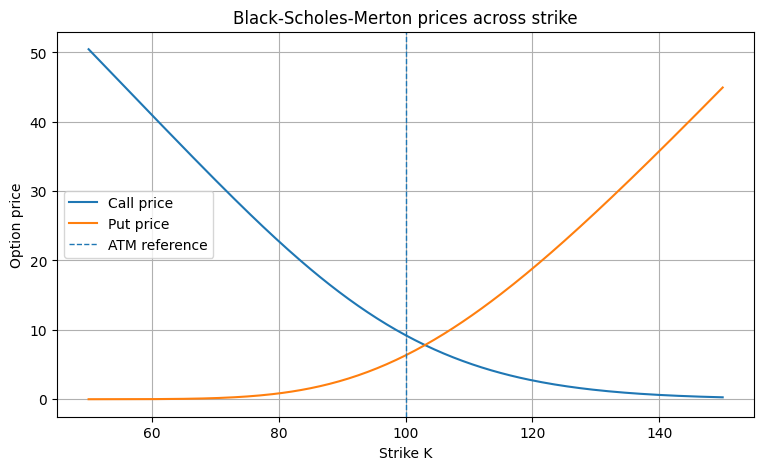

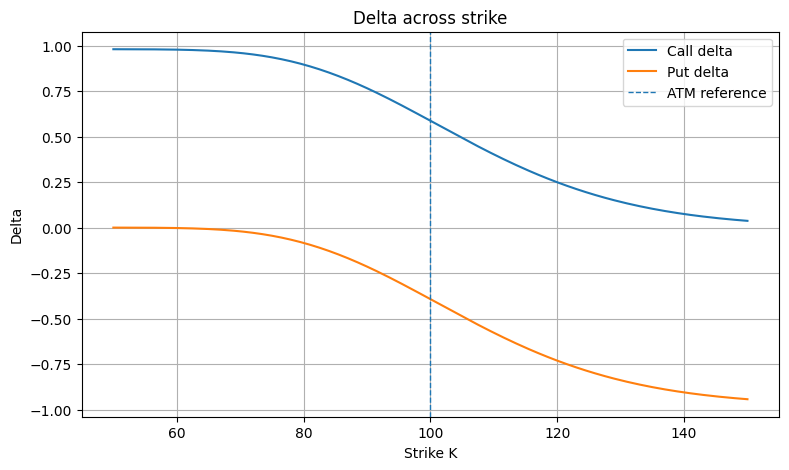

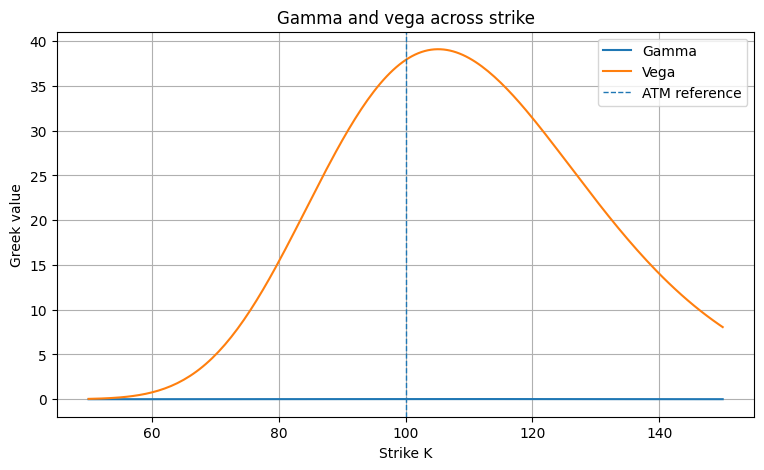

In [7]:
# ============================================================
# Strike-profile diagnostics: prices and Greeks across moneyness
# ============================================================

def build_strike_profile(
    base: BlackScholesInputs,
    k_min: float = 50.0,
    k_max: float = 150.0,
    n: int = 201,
) -> pd.DataFrame:
    """
    Build call/put price and Greek profiles across strikes while holding
    S, tau, r, q, and sigma fixed.
    """
    strikes = np.linspace(k_min, k_max, n)

    profile = pd.DataFrame(
        {
            "S": base.S,
            "K": strikes,
            "moneyness_K_over_S": strikes / base.S,
            "tau": base.tau,
            "r": base.r,
            "q": base.q,
            "sigma": base.sigma,
        }
    )

    profile["call_price"] = bsm_call_price(
        profile["S"].to_numpy(),
        profile["K"].to_numpy(),
        profile["tau"].to_numpy(),
        profile["r"].to_numpy(),
        profile["q"].to_numpy(),
        profile["sigma"].to_numpy(),
    )

    profile["put_price"] = bsm_put_price(
        profile["S"].to_numpy(),
        profile["K"].to_numpy(),
        profile["tau"].to_numpy(),
        profile["r"].to_numpy(),
        profile["q"].to_numpy(),
        profile["sigma"].to_numpy(),
    )

    profile["call_delta"] = bsm_call_delta(
        profile["S"].to_numpy(),
        profile["K"].to_numpy(),
        profile["tau"].to_numpy(),
        profile["r"].to_numpy(),
        profile["q"].to_numpy(),
        profile["sigma"].to_numpy(),
    )

    profile["put_delta"] = bsm_put_delta(
        profile["S"].to_numpy(),
        profile["K"].to_numpy(),
        profile["tau"].to_numpy(),
        profile["r"].to_numpy(),
        profile["q"].to_numpy(),
        profile["sigma"].to_numpy(),
    )

    profile["gamma"] = bsm_gamma(
        profile["S"].to_numpy(),
        profile["K"].to_numpy(),
        profile["tau"].to_numpy(),
        profile["r"].to_numpy(),
        profile["q"].to_numpy(),
        profile["sigma"].to_numpy(),
    )

    profile["vega"] = bsm_vega(
        profile["S"].to_numpy(),
        profile["K"].to_numpy(),
        profile["tau"].to_numpy(),
        profile["r"].to_numpy(),
        profile["q"].to_numpy(),
        profile["sigma"].to_numpy(),
    )

    profile["call_theta"] = bsm_call_theta(
        profile["S"].to_numpy(),
        profile["K"].to_numpy(),
        profile["tau"].to_numpy(),
        profile["r"].to_numpy(),
        profile["q"].to_numpy(),
        profile["sigma"].to_numpy(),
    )

    profile["put_theta"] = bsm_put_theta(
        profile["S"].to_numpy(),
        profile["K"].to_numpy(),
        profile["tau"].to_numpy(),
        profile["r"].to_numpy(),
        profile["q"].to_numpy(),
        profile["sigma"].to_numpy(),
    )

    return profile


def monotonicity_violation_count(values: np.ndarray, direction: str, tol: float = 1e-10) -> int:
    """
    Count monotonicity violations.

    direction='nonincreasing': next value should be <= previous value
    direction='nondecreasing': next value should be >= previous value
    """
    diffs = np.diff(np.asarray(values, dtype=float))

    if direction == "nonincreasing":
        return int(np.sum(diffs > tol))

    if direction == "nondecreasing":
        return int(np.sum(diffs < -tol))

    raise ValueError("direction must be 'nonincreasing' or 'nondecreasing'.")


strike_profile = build_strike_profile(BASE)

strike_behavior_audit = pd.DataFrame(
    [
        {
            "check": "call_price_nonincreasing_in_strike",
            "violation_count": monotonicity_violation_count(
                strike_profile["call_price"].to_numpy(),
                direction="nonincreasing",
            ),
            "passed": monotonicity_violation_count(
                strike_profile["call_price"].to_numpy(),
                direction="nonincreasing",
            )
            == 0,
        },
        {
            "check": "put_price_nondecreasing_in_strike",
            "violation_count": monotonicity_violation_count(
                strike_profile["put_price"].to_numpy(),
                direction="nondecreasing",
            ),
            "passed": monotonicity_violation_count(
                strike_profile["put_price"].to_numpy(),
                direction="nondecreasing",
            )
            == 0,
        },
        {
            "check": "call_delta_nonincreasing_in_strike",
            "violation_count": monotonicity_violation_count(
                strike_profile["call_delta"].to_numpy(),
                direction="nonincreasing",
            ),
            "passed": monotonicity_violation_count(
                strike_profile["call_delta"].to_numpy(),
                direction="nonincreasing",
            )
            == 0,
        },
        {
            "check": "put_delta_nonincreasing_in_strike",
            "violation_count": monotonicity_violation_count(
                strike_profile["put_delta"].to_numpy(),
                direction="nonincreasing",
            ),
            "passed": monotonicity_violation_count(
                strike_profile["put_delta"].to_numpy(),
                direction="nonincreasing",
            )
            == 0,
        },
        {
            "check": "gamma_nonnegative",
            "violation_count": int(np.sum(strike_profile["gamma"].to_numpy() < -1e-12)),
            "passed": bool(np.all(strike_profile["gamma"].to_numpy() >= -1e-12)),
        },
        {
            "check": "vega_nonnegative",
            "violation_count": int(np.sum(strike_profile["vega"].to_numpy() < -1e-12)),
            "passed": bool(np.all(strike_profile["vega"].to_numpy() >= -1e-12)),
        },
    ]
)

print("Strike-profile behavior audit:")
display(strike_behavior_audit)

print("Selected strike-profile rows:")
display(
    strike_profile.loc[
        strike_profile["K"].isin([60.0, 80.0, 100.0, 120.0, 140.0]),
        [
            "K",
            "moneyness_K_over_S",
            "call_price",
            "put_price",
            "call_delta",
            "put_delta",
            "gamma",
            "vega",
            "call_theta",
            "put_theta",
        ],
    ]
)

fig, ax = plt.subplots()
ax.plot(strike_profile["K"], strike_profile["call_price"], label="Call price")
ax.plot(strike_profile["K"], strike_profile["put_price"], label="Put price")
ax.axvline(BASE.S, linestyle="--", linewidth=1, label="ATM reference")
ax.set_title("Black-Scholes-Merton prices across strike")
ax.set_xlabel("Strike K")
ax.set_ylabel("Option price")
ax.legend()
plt.show()

fig, ax = plt.subplots()
ax.plot(strike_profile["K"], strike_profile["call_delta"], label="Call delta")
ax.plot(strike_profile["K"], strike_profile["put_delta"], label="Put delta")
ax.axvline(BASE.S, linestyle="--", linewidth=1, label="ATM reference")
ax.set_title("Delta across strike")
ax.set_xlabel("Strike K")
ax.set_ylabel("Delta")
ax.legend()
plt.show()

fig, ax = plt.subplots()
ax.plot(strike_profile["K"], strike_profile["gamma"], label="Gamma")
ax.plot(strike_profile["K"], strike_profile["vega"], label="Vega")
ax.axvline(BASE.S, linestyle="--", linewidth=1, label="ATM reference")
ax.set_title("Gamma and vega across strike")
ax.set_xlabel("Strike K")
ax.set_ylabel("Greek value")
ax.legend()
plt.show()

if not bool(strike_behavior_audit["passed"].all()):
    raise AssertionError("Strike-profile behavior audit failed.")

Volatility and maturity behavior audit:


,check,violation_count,passed
0,call_price_nondecreasing_in_volatility,0,True
1,put_price_nondecreasing_in_volatility,0,True
2,volatility_profile_prices_finite,0,True
3,maturity_profile_prices_finite,0,True
4,maturity_profile_greeks_finite,0,True


Selected maturity-profile rows:


,tau,call_price,put_price,call_delta,put_delta,gamma,vega,call_theta,put_theta
0,0.0039682540,0.5085208919,0.4966177833,0.5062423111,-0.4936783270,0.3165862268,2.5125891014,-64.8105462448,-61.8113794860
29,0.4383928571,5.8719278487,4.5767656863,0.5607972260,-0.4304732424,0.0294571527,25.8276106676,-7.2802258249,-4.3711725277
57,0.8578373016,8.4792729552,5.9818116051,0.5814931437,-0.4014964491,0.0206102953,35.3605601767,-5.4425748395,-2.6184791285
86,1.2922619048,10.6297713236,6.9241911391,0.5962579391,-0.3782279522,0.0164226093,42.4446247333,-4.5418071097,-1.8036284452
114,1.7117063492,12.4127736950,7.5757326727,0.6070546879,-0.3592905427,0.0139658373,47.8108246700,-3.9936928339,-1.3365091931
143,2.1461309524,14.0546054980,8.0810812248,0.6158963023,-0.3420892147,0.0121978771,52.3564832232,-3.5845340533,-1.0092537159
171,2.5655753968,15.4913966608,8.4539406065,0.6227916048,-0.3271910924,0.0109190322,56.0272009218,-3.2776114286,-0.7795361395
200,3.0000000000,16.8571400668,8.7514843508,0.6286252165,-0.3131393171,0.0098752174,59.2513045277,-3.0180621304,-0.5980513154


Selected volatility-profile rows:


,sigma,call_price,put_price,call_delta,put_delta,gamma,vega
0,0.0000000000,2.8969248806,0.0000000000,NaN,NaN,NaN,NaN
20,0.1000000000,5.4713485779,2.5744236973,0.6242205594,-0.3559781139,0.0367810090,36.7810090219
40,0.2000000000,9.2270055082,6.3300806275,0.5868511461,-0.3933475272,0.0189505788,37.9011575100
80,0.4000000000,16.7993655253,13.9024406447,0.5962959045,-0.3839027688,0.0094133114,37.6532455148
120,0.6000000000,24.2498208527,21.3528959721,0.6242205594,-0.3559781139,0.0061301682,36.7810090219
160,0.8000000000,31.4870550521,28.5901301715,0.6558760371,-0.3243226362,0.0044419212,35.5353696194
200,1.0000000000,38.4433573463,35.5464324657,0.6880446115,-0.2921540619,0.0033980324,33.9803240532


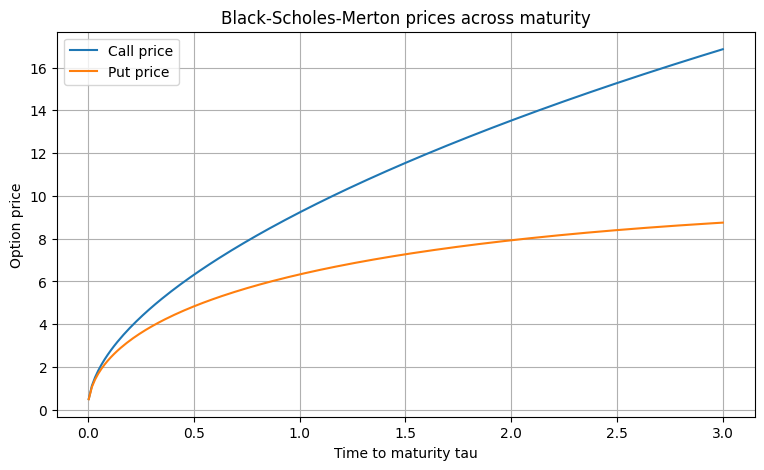

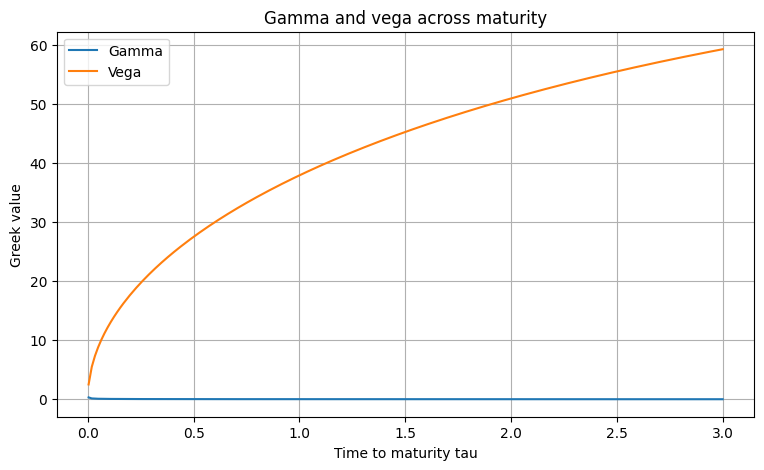

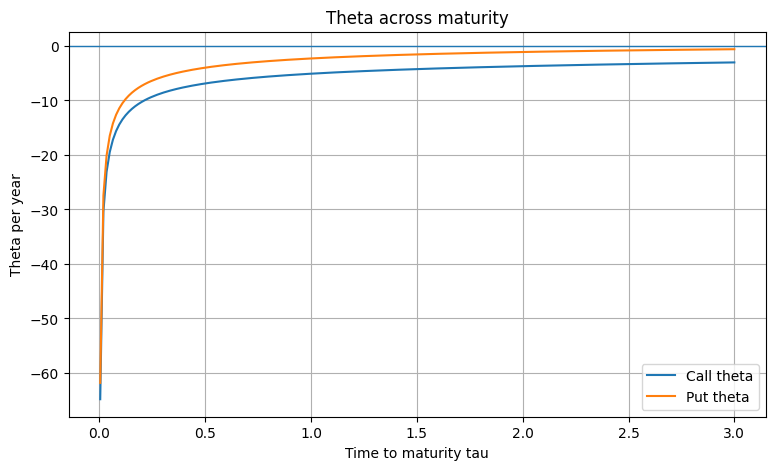

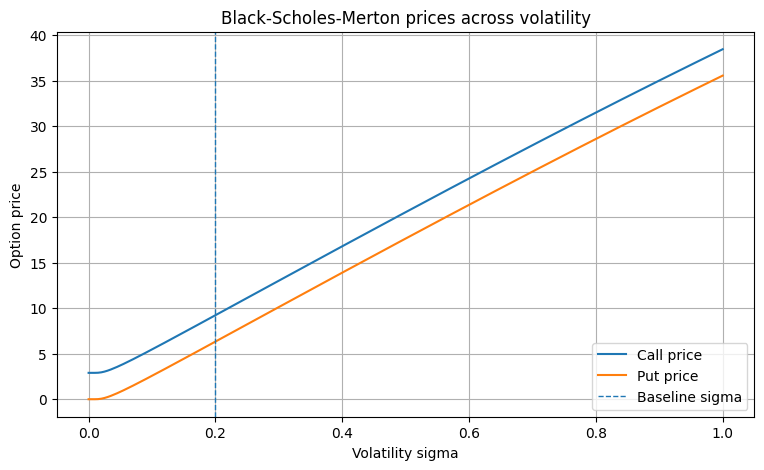

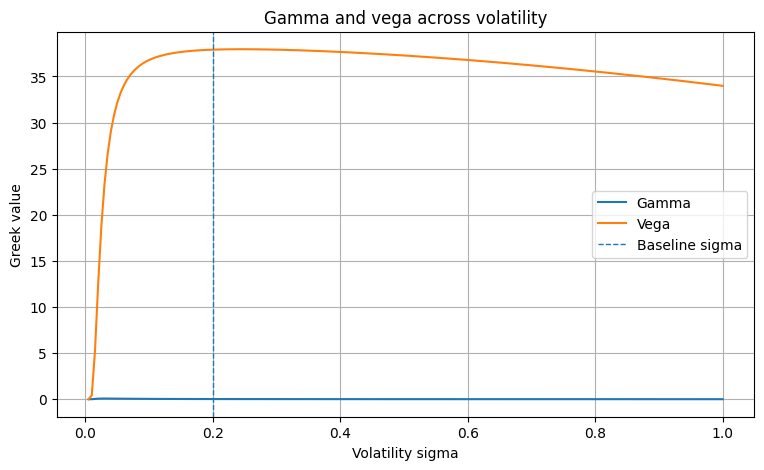

In [8]:
# ============================================================
# Volatility and maturity behavior diagnostics
# ============================================================

def build_volatility_profile(
    base: BlackScholesInputs,
    sigma_min: float = 0.0,
    sigma_max: float = 1.0,
    n: int = 201,
) -> pd.DataFrame:
    """
    Build price and Greek profiles across volatility while holding
    S, K, tau, r, and q fixed.

    sigma = 0 is included because the price functions explicitly handle
    the deterministic limiting case. Greeks at sigma = 0 are left as NaN
    because the smooth Black-Scholes sensitivities are not well-defined there.
    """
    sigmas = np.linspace(sigma_min, sigma_max, n)

    profile = pd.DataFrame(
        {
            "S": base.S,
            "K": base.K,
            "tau": base.tau,
            "r": base.r,
            "q": base.q,
            "sigma": sigmas,
        }
    )

    profile["call_price"] = bsm_call_price(
        profile["S"].to_numpy(),
        profile["K"].to_numpy(),
        profile["tau"].to_numpy(),
        profile["r"].to_numpy(),
        profile["q"].to_numpy(),
        profile["sigma"].to_numpy(),
    )

    profile["put_price"] = bsm_put_price(
        profile["S"].to_numpy(),
        profile["K"].to_numpy(),
        profile["tau"].to_numpy(),
        profile["r"].to_numpy(),
        profile["q"].to_numpy(),
        profile["sigma"].to_numpy(),
    )

    positive_sigma = profile["sigma"].to_numpy() > 0.0

    profile["call_delta"] = np.nan
    profile["put_delta"] = np.nan
    profile["gamma"] = np.nan
    profile["vega"] = np.nan

    profile.loc[positive_sigma, "call_delta"] = bsm_call_delta(
        profile.loc[positive_sigma, "S"].to_numpy(),
        profile.loc[positive_sigma, "K"].to_numpy(),
        profile.loc[positive_sigma, "tau"].to_numpy(),
        profile.loc[positive_sigma, "r"].to_numpy(),
        profile.loc[positive_sigma, "q"].to_numpy(),
        profile.loc[positive_sigma, "sigma"].to_numpy(),
    )

    profile.loc[positive_sigma, "put_delta"] = bsm_put_delta(
        profile.loc[positive_sigma, "S"].to_numpy(),
        profile.loc[positive_sigma, "K"].to_numpy(),
        profile.loc[positive_sigma, "tau"].to_numpy(),
        profile.loc[positive_sigma, "r"].to_numpy(),
        profile.loc[positive_sigma, "q"].to_numpy(),
        profile.loc[positive_sigma, "sigma"].to_numpy(),
    )

    profile.loc[positive_sigma, "gamma"] = bsm_gamma(
        profile.loc[positive_sigma, "S"].to_numpy(),
        profile.loc[positive_sigma, "K"].to_numpy(),
        profile.loc[positive_sigma, "tau"].to_numpy(),
        profile.loc[positive_sigma, "r"].to_numpy(),
        profile.loc[positive_sigma, "q"].to_numpy(),
        profile.loc[positive_sigma, "sigma"].to_numpy(),
    )

    profile.loc[positive_sigma, "vega"] = bsm_vega(
        profile.loc[positive_sigma, "S"].to_numpy(),
        profile.loc[positive_sigma, "K"].to_numpy(),
        profile.loc[positive_sigma, "tau"].to_numpy(),
        profile.loc[positive_sigma, "r"].to_numpy(),
        profile.loc[positive_sigma, "q"].to_numpy(),
        profile.loc[positive_sigma, "sigma"].to_numpy(),
    )

    return profile


def build_maturity_profile(
    base: BlackScholesInputs,
    tau_min: float = 1.0 / 252.0,
    tau_max: float = 3.0,
    n: int = 201,
) -> pd.DataFrame:
    """
    Build price and Greek profiles across time to maturity while holding
    S, K, r, q, and sigma fixed.

    tau = 0 is excluded here because gamma, vega, and theta become singular
    or discontinuous at expiry. Expiry convergence is checked separately.
    """
    taus = np.linspace(tau_min, tau_max, n)

    profile = pd.DataFrame(
        {
            "S": base.S,
            "K": base.K,
            "tau": taus,
            "r": base.r,
            "q": base.q,
            "sigma": base.sigma,
        }
    )

    profile["call_price"] = bsm_call_price(
        profile["S"].to_numpy(),
        profile["K"].to_numpy(),
        profile["tau"].to_numpy(),
        profile["r"].to_numpy(),
        profile["q"].to_numpy(),
        profile["sigma"].to_numpy(),
    )

    profile["put_price"] = bsm_put_price(
        profile["S"].to_numpy(),
        profile["K"].to_numpy(),
        profile["tau"].to_numpy(),
        profile["r"].to_numpy(),
        profile["q"].to_numpy(),
        profile["sigma"].to_numpy(),
    )

    profile["call_delta"] = bsm_call_delta(
        profile["S"].to_numpy(),
        profile["K"].to_numpy(),
        profile["tau"].to_numpy(),
        profile["r"].to_numpy(),
        profile["q"].to_numpy(),
        profile["sigma"].to_numpy(),
    )

    profile["put_delta"] = bsm_put_delta(
        profile["S"].to_numpy(),
        profile["K"].to_numpy(),
        profile["tau"].to_numpy(),
        profile["r"].to_numpy(),
        profile["q"].to_numpy(),
        profile["sigma"].to_numpy(),
    )

    profile["gamma"] = bsm_gamma(
        profile["S"].to_numpy(),
        profile["K"].to_numpy(),
        profile["tau"].to_numpy(),
        profile["r"].to_numpy(),
        profile["q"].to_numpy(),
        profile["sigma"].to_numpy(),
    )

    profile["vega"] = bsm_vega(
        profile["S"].to_numpy(),
        profile["K"].to_numpy(),
        profile["tau"].to_numpy(),
        profile["r"].to_numpy(),
        profile["q"].to_numpy(),
        profile["sigma"].to_numpy(),
    )

    profile["call_theta"] = bsm_call_theta(
        profile["S"].to_numpy(),
        profile["K"].to_numpy(),
        profile["tau"].to_numpy(),
        profile["r"].to_numpy(),
        profile["q"].to_numpy(),
        profile["sigma"].to_numpy(),
    )

    profile["put_theta"] = bsm_put_theta(
        profile["S"].to_numpy(),
        profile["K"].to_numpy(),
        profile["tau"].to_numpy(),
        profile["r"].to_numpy(),
        profile["q"].to_numpy(),
        profile["sigma"].to_numpy(),
    )

    return profile


def evenly_spaced_row_positions(n_rows: int, n_points: int = 8) -> list[int]:
    """
    Return valid, unique row positions spread across a DataFrame.

    This avoids hard-coded row positions that can break when the profile
    length changes.
    """
    if n_rows <= 0:
        return []

    positions = np.linspace(0, n_rows - 1, min(n_points, n_rows))
    return sorted(set(int(round(pos)) for pos in positions))


# -----------------------------
# Build profiles
# -----------------------------

volatility_profile = build_volatility_profile(BASE)
maturity_profile = build_maturity_profile(BASE)


# -----------------------------
# Audit behavior
# -----------------------------

call_vol_violations = monotonicity_violation_count(
    volatility_profile["call_price"].to_numpy(),
    direction="nondecreasing",
)

put_vol_violations = monotonicity_violation_count(
    volatility_profile["put_price"].to_numpy(),
    direction="nondecreasing",
)

volatility_behavior_audit = pd.DataFrame(
    [
        {
            "check": "call_price_nondecreasing_in_volatility",
            "violation_count": call_vol_violations,
            "passed": call_vol_violations == 0,
        },
        {
            "check": "put_price_nondecreasing_in_volatility",
            "violation_count": put_vol_violations,
            "passed": put_vol_violations == 0,
        },
        {
            "check": "volatility_profile_prices_finite",
            "violation_count": int(
                (~np.isfinite(volatility_profile[["call_price", "put_price"]].to_numpy())).sum()
            ),
            "passed": bool(
                np.isfinite(volatility_profile[["call_price", "put_price"]].to_numpy()).all()
            ),
        },
        {
            "check": "maturity_profile_prices_finite",
            "violation_count": int(
                (~np.isfinite(maturity_profile[["call_price", "put_price"]].to_numpy())).sum()
            ),
            "passed": bool(
                np.isfinite(maturity_profile[["call_price", "put_price"]].to_numpy()).all()
            ),
        },
        {
            "check": "maturity_profile_greeks_finite",
            "violation_count": int(
                (
                    ~np.isfinite(
                        maturity_profile[
                            [
                                "call_delta",
                                "put_delta",
                                "gamma",
                                "vega",
                                "call_theta",
                                "put_theta",
                            ]
                        ].to_numpy()
                    )
                ).sum()
            ),
            "passed": bool(
                np.isfinite(
                    maturity_profile[
                        [
                            "call_delta",
                            "put_delta",
                            "gamma",
                            "vega",
                            "call_theta",
                            "put_theta",
                        ]
                    ].to_numpy()
                ).all()
            ),
        },
    ]
)

print("Volatility and maturity behavior audit:")
display(volatility_behavior_audit)


# -----------------------------
# Display selected profile rows
# -----------------------------

maturity_columns = [
    "tau",
    "call_price",
    "put_price",
    "call_delta",
    "put_delta",
    "gamma",
    "vega",
    "call_theta",
    "put_theta",
]

volatility_columns = [
    "sigma",
    "call_price",
    "put_price",
    "call_delta",
    "put_delta",
    "gamma",
    "vega",
]

maturity_positions = evenly_spaced_row_positions(len(maturity_profile), n_points=8)

selected_sigmas = [0.0, 0.1, 0.2, 0.4, 0.6, 0.8, 1.0]
selected_volatility_rows = volatility_profile.loc[
    np.isclose(volatility_profile["sigma"].to_numpy()[:, None], selected_sigmas).any(axis=1),
    volatility_columns,
]

print("Selected maturity-profile rows:")
display(maturity_profile.iloc[maturity_positions].loc[:, maturity_columns])

print("Selected volatility-profile rows:")
display(selected_volatility_rows)


# -----------------------------
# Plots
# -----------------------------

fig, ax = plt.subplots()
ax.plot(maturity_profile["tau"], maturity_profile["call_price"], label="Call price")
ax.plot(maturity_profile["tau"], maturity_profile["put_price"], label="Put price")
ax.set_title("Black-Scholes-Merton prices across maturity")
ax.set_xlabel("Time to maturity tau")
ax.set_ylabel("Option price")
ax.legend()
plt.show()

fig, ax = plt.subplots()
ax.plot(maturity_profile["tau"], maturity_profile["gamma"], label="Gamma")
ax.plot(maturity_profile["tau"], maturity_profile["vega"], label="Vega")
ax.set_title("Gamma and vega across maturity")
ax.set_xlabel("Time to maturity tau")
ax.set_ylabel("Greek value")
ax.legend()
plt.show()

fig, ax = plt.subplots()
ax.plot(maturity_profile["tau"], maturity_profile["call_theta"], label="Call theta")
ax.plot(maturity_profile["tau"], maturity_profile["put_theta"], label="Put theta")
ax.axhline(0.0, linewidth=1)
ax.set_title("Theta across maturity")
ax.set_xlabel("Time to maturity tau")
ax.set_ylabel("Theta per year")
ax.legend()
plt.show()

fig, ax = plt.subplots()
ax.plot(volatility_profile["sigma"], volatility_profile["call_price"], label="Call price")
ax.plot(volatility_profile["sigma"], volatility_profile["put_price"], label="Put price")
ax.axvline(BASE.sigma, linestyle="--", linewidth=1, label="Baseline sigma")
ax.set_title("Black-Scholes-Merton prices across volatility")
ax.set_xlabel("Volatility sigma")
ax.set_ylabel("Option price")
ax.legend()
plt.show()

fig, ax = plt.subplots()
positive_sigma_profile = volatility_profile.loc[volatility_profile["sigma"] > 0].copy()
ax.plot(positive_sigma_profile["sigma"], positive_sigma_profile["gamma"], label="Gamma")
ax.plot(positive_sigma_profile["sigma"], positive_sigma_profile["vega"], label="Vega")
ax.axvline(BASE.sigma, linestyle="--", linewidth=1, label="Baseline sigma")
ax.set_title("Gamma and vega across volatility")
ax.set_xlabel("Volatility sigma")
ax.set_ylabel("Greek value")
ax.legend()
plt.show()

if not bool(volatility_behavior_audit["passed"].all()):
    raise AssertionError("Volatility or maturity behavior audit failed.")

In [9]:
# ============================================================
# Limiting-case and edge-case diagnostics
# ============================================================

def intrinsic_call_value(S: Any, K: Any) -> float | np.ndarray:
    """
    European call intrinsic value at expiry.
    """
    scalar_output = _all_inputs_are_scalar(S, K)
    S_arr, K_arr = _broadcast_float_inputs(S, K)

    value = np.maximum(S_arr - K_arr, 0.0)

    return _return_scalar_if_needed(value, scalar_output)


def intrinsic_put_value(S: Any, K: Any) -> float | np.ndarray:
    """
    European put intrinsic value at expiry.
    """
    scalar_output = _all_inputs_are_scalar(S, K)
    S_arr, K_arr = _broadcast_float_inputs(S, K)

    value = np.maximum(K_arr - S_arr, 0.0)

    return _return_scalar_if_needed(value, scalar_output)


def build_near_expiry_check(
    base: BlackScholesInputs,
    tau_values: list[float] | None = None,
) -> pd.DataFrame:
    """
    Check that option prices converge toward intrinsic value as tau approaches zero.
    """
    if tau_values is None:
        tau_values = [0.0, 1e-10, 1e-8, 1e-6, 1e-4, 1.0 / 252.0]

    rows = []

    for tau in tau_values:
        call_price = bsm_call_price(base.S, base.K, tau, base.r, base.q, base.sigma)
        put_price = bsm_put_price(base.S, base.K, tau, base.r, base.q, base.sigma)

        call_intrinsic = intrinsic_call_value(base.S, base.K)
        put_intrinsic = intrinsic_put_value(base.S, base.K)

        rows.append(
            {
                "tau": tau,
                "call_price": call_price,
                "call_intrinsic": call_intrinsic,
                "call_abs_error_vs_intrinsic": abs(call_price - call_intrinsic),
                "put_price": put_price,
                "put_intrinsic": put_intrinsic,
                "put_abs_error_vs_intrinsic": abs(put_price - put_intrinsic),
            }
        )

    return pd.DataFrame(rows)


def build_zero_volatility_check(base: BlackScholesInputs) -> pd.DataFrame:
    """
    Check that sigma = 0 prices equal deterministic discounted payoff values.
    """
    test_cases = [
        {"case": "deep_put_itm", "S": 60.0, "K": 100.0},
        {"case": "atm", "S": 100.0, "K": 100.0},
        {"case": "deep_call_itm", "S": 140.0, "K": 100.0},
    ]

    rows = []

    for case in test_cases:
        S = case["S"]
        K = case["K"]

        call_price = bsm_call_price(S, K, base.tau, base.r, base.q, 0.0)
        put_price = bsm_put_price(S, K, base.tau, base.r, base.q, 0.0)

        call_deterministic = deterministic_call_value(S, K, base.tau, base.r, base.q)
        put_deterministic = deterministic_put_value(S, K, base.tau, base.r, base.q)

        rows.append(
            {
                "case": case["case"],
                "S": S,
                "K": K,
                "tau": base.tau,
                "r": base.r,
                "q": base.q,
                "sigma": 0.0,
                "call_price": call_price,
                "call_deterministic_value": call_deterministic,
                "call_abs_error": abs(call_price - call_deterministic),
                "put_price": put_price,
                "put_deterministic_value": put_deterministic,
                "put_abs_error": abs(put_price - put_deterministic),
            }
        )

    return pd.DataFrame(rows)


def build_extreme_moneyness_check(base: BlackScholesInputs) -> pd.DataFrame:
    """
    Check deep ITM and deep OTM option behavior.
    """
    test_cases = [
        {"case": "deep_call_itm_put_otm", "S": 100.0, "K": 1.0},
        {"case": "deep_call_otm_put_itm", "S": 100.0, "K": 1_000.0},
    ]

    rows = []

    for case in test_cases:
        S = case["S"]
        K = case["K"]

        discounted_spot = S * math.exp(-base.q * base.tau)
        discounted_strike = K * math.exp(-base.r * base.tau)

        call_price = bsm_call_price(S, K, base.tau, base.r, base.q, base.sigma)
        put_price = bsm_put_price(S, K, base.tau, base.r, base.q, base.sigma)

        call_lower_bound = max(discounted_spot - discounted_strike, 0.0)
        put_lower_bound = max(discounted_strike - discounted_spot, 0.0)

        rows.append(
            {
                "case": case["case"],
                "S": S,
                "K": K,
                "discounted_spot": discounted_spot,
                "discounted_strike": discounted_strike,
                "call_price": call_price,
                "call_lower_bound": call_lower_bound,
                "call_abs_error_vs_bound": abs(call_price - call_lower_bound),
                "put_price": put_price,
                "put_lower_bound": put_lower_bound,
                "put_abs_error_vs_bound": abs(put_price - put_lower_bound),
            }
        )

    return pd.DataFrame(rows)


def build_high_volatility_check(
    base: BlackScholesInputs,
    sigma_values: list[float] | None = None,
) -> pd.DataFrame:
    """
    Check that very high volatility prices remain finite and inside
    no-arbitrage upper bounds.
    """
    if sigma_values is None:
        sigma_values = [1.0, 2.0, 3.0, 5.0]

    rows = []

    for sigma in sigma_values:
        call_price = bsm_call_price(base.S, base.K, base.tau, base.r, base.q, sigma)
        put_price = bsm_put_price(base.S, base.K, base.tau, base.r, base.q, sigma)

        call_upper_bound = base.S * math.exp(-base.q * base.tau)
        put_upper_bound = base.K * math.exp(-base.r * base.tau)

        rows.append(
            {
                "sigma": sigma,
                "call_price": call_price,
                "call_upper_bound": call_upper_bound,
                "call_upper_bound_slack": call_upper_bound - call_price,
                "put_price": put_price,
                "put_upper_bound": put_upper_bound,
                "put_upper_bound_slack": put_upper_bound - put_price,
                "prices_finite": bool(np.isfinite(call_price) and np.isfinite(put_price)),
                "inside_upper_bounds": bool(
                    call_price <= call_upper_bound + BOUNDS_TOL
                    and put_price <= put_upper_bound + BOUNDS_TOL
                ),
            }
        )

    return pd.DataFrame(rows)


# -----------------------------
# Run limiting-case checks
# -----------------------------

near_expiry_check = build_near_expiry_check(BASE)
zero_volatility_check = build_zero_volatility_check(BASE)
extreme_moneyness_check = build_extreme_moneyness_check(BASE)
high_volatility_check = build_high_volatility_check(BASE)

near_expiry_focus = near_expiry_check.loc[near_expiry_check["tau"] <= 1e-8].copy()

near_expiry_max_error = float(
    near_expiry_focus[
        ["call_abs_error_vs_intrinsic", "put_abs_error_vs_intrinsic"]
    ].to_numpy().max()
)

zero_vol_max_error = float(
    zero_volatility_check[
        ["call_abs_error", "put_abs_error"]
    ].to_numpy().max()
)

extreme_moneyness_max_error = float(
    extreme_moneyness_check[
        ["call_abs_error_vs_bound", "put_abs_error_vs_bound"]
    ].to_numpy().max()
)

high_vol_upper_bound_violations = int(
    (~high_volatility_check["inside_upper_bounds"]).sum()
)

edge_case_audit_summary = pd.DataFrame(
    [
        {
            "check": "near_expiry_converges_to_intrinsic",
            "metric": near_expiry_max_error,
            "threshold": 1e-3,
            "passed": near_expiry_max_error <= 1e-3,
        },
        {
            "check": "zero_volatility_matches_deterministic_value",
            "metric": zero_vol_max_error,
            "threshold": 1e-12,
            "passed": zero_vol_max_error <= 1e-12,
        },
        {
            "check": "extreme_moneyness_near_lower_bound",
            "metric": extreme_moneyness_max_error,
            "threshold": 1e-8,
            "passed": extreme_moneyness_max_error <= 1e-8,
        },
        {
            "check": "high_volatility_prices_inside_upper_bounds",
            "metric": high_vol_upper_bound_violations,
            "threshold": 0.0,
            "passed": high_vol_upper_bound_violations == 0,
        },
        {
            "check": "high_volatility_prices_finite",
            "metric": int((~high_volatility_check["prices_finite"]).sum()),
            "threshold": 0.0,
            "passed": bool(high_volatility_check["prices_finite"].all()),
        },
    ]
)

print("Limiting-case and edge-case audit:")
display(edge_case_audit_summary)

print("Near-expiry convergence check:")
display(near_expiry_check)

print("Zero-volatility deterministic payoff check:")
display(zero_volatility_check)

print("Extreme moneyness check:")
display(extreme_moneyness_check)

print("High-volatility upper-bound check:")
display(high_volatility_check)

if not bool(edge_case_audit_summary["passed"].all()):
    raise AssertionError("One or more limiting-case or edge-case checks failed.")

Limiting-case and edge-case audit:


,check,metric,threshold,passed
0,near_expiry_converges_to_intrinsic,0.0007978996,0.0010000000,True
1,zero_volatility_matches_deterministic_value,0.0000000000,0.0000000000,True
2,extreme_moneyness_near_lower_bound,0.0000000000,0.0000000100,True
3,high_volatility_prices_inside_upper_bounds,0.0000000000,0.0000000000,True
4,high_volatility_prices_finite,0.0000000000,0.0000000000,True


Near-expiry convergence check:


,tau,call_price,call_intrinsic,call_abs_error_vs_intrinsic,put_price,put_intrinsic,put_abs_error_vs_intrinsic
0,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000
1,0.0000000001,0.0000797886,0.0000000000,0.0000797886,0.0000797883,0.0000000000,0.0000797883
2,0.0000000100,0.0007978996,0.0000000000,0.0007978996,0.0007978696,0.0000000000,0.0007978696
3,0.0000010000,0.0079803454,0.0000000000,0.0079803454,0.0079773454,0.0000000000,0.0079773454
4,0.0001000000,0.0799382528,0.0000000000,0.0799382528,0.0796382538,0.0000000000,0.0796382538
5,0.0039682540,0.5085208919,0.0000000000,0.5085208919,0.4966177833,0.0000000000,0.4966177833


Zero-volatility deterministic payoff check:


,case,S,K,tau,r,q,sigma,call_price,call_deterministic_value,call_abs_error,put_price,put_deterministic_value,put_abs_error
0,deep_put_itm,60.0000000000,100.0000000000,1.0000000000,0.0500000000,0.0200000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,36.3110220517,36.3110220517,0.0000000000
1,atm,100.0000000000,100.0000000000,1.0000000000,0.0500000000,0.0200000000,0.0000000000,2.8969248806,2.8969248806,0.0000000000,0.0000000000,0.0000000000,0.0000000000
2,deep_call_itm,140.0000000000,100.0000000000,1.0000000000,0.0500000000,0.0200000000,0.0000000000,42.1048718129,42.1048718129,0.0000000000,0.0000000000,0.0000000000,0.0000000000


Extreme moneyness check:


,case,S,K,discounted_spot,discounted_strike,call_price,call_lower_bound,call_abs_error_vs_bound,put_price,put_lower_bound,put_abs_error_vs_bound
0,deep_call_itm_put_otm,100.0000000000,1.0000000000,98.0198673307,0.9512294245,97.0686379062,97.0686379062,0.0000000000,0.0000000000,0.0000000000,0.0000000000
1,deep_call_otm_put_itm,100.0000000000,"1,000.0000000000",98.0198673307,951.2294245007,0.0000000000,0.0000000000,0.0000000000,853.2095571700,853.2095571700,0.0000000000


High-volatility upper-bound check:


,sigma,call_price,call_upper_bound,call_upper_bound_slack,put_price,put_upper_bound,put_upper_bound_slack,prices_finite,inside_upper_bounds
0,1.0000000000,38.4433573463,98.0198673307,59.5765099844,35.5464324657,95.1229424501,59.5765099844,True,True
1,2.0000000000,67.3820028853,98.0198673307,30.6378644453,64.4850780047,95.1229424501,30.6378644453,True,True
2,3.0000000000,85.1184127269,98.0198673307,12.9014546037,82.2214878463,95.1229424501,12.9014546037,True,True
3,5.0000000000,96.8206674531,98.0198673307,1.1991998776,93.9237425724,95.1229424501,1.1991998776,True,True


CRR binomial convergence audit:


,check,metric,threshold,passed
0,crr_call_final_error_within_tolerance,0.0018982188,0.0200000000,True
1,crr_put_final_error_within_tolerance,0.0018982188,0.0200000000,True
2,crr_call_error_improves_from_n1,0.0010279895,1.0000000000,True
3,crr_put_error_improves_from_n1,0.0010279895,1.0000000000,True


CRR convergence table:


,n_steps,bs_call,crr_call,call_abs_error,bs_put,crr_put,put_abs_error
0,1,9.2270055082,11.0735407038,1.8465351957,6.3300806275,8.1766158232,1.8465351957
1,2,9.2270055082,8.3422930612,0.8847124469,6.3300806275,5.4453681806,0.8847124469
2,4,9.2270055082,8.7603273153,0.4666781928,6.3300806275,5.8634024347,0.4666781928
3,8,9.2270055082,8.9883628964,0.2386426118,6.3300806275,6.0914380158,0.2386426118
4,16,9.2270055082,9.1065262129,0.1204792952,6.3300806275,6.2096013323,0.1204792952
5,32,9.2270055082,9.1665015042,0.0605040039,6.3300806275,6.2695766236,0.0605040039
6,64,9.2270055082,9.1966907589,0.0303147492,6.3300806275,6.2997658783,0.0303147492
7,128,9.2270055082,9.2118328740,0.0151726341,6.3300806275,6.3149079934,0.0151726341
8,256,9.2270055082,9.2194154301,0.0075900780,6.3300806275,6.3224905495,0.0075900780
9,512,9.2270055082,9.2232095357,0.0037959725,6.3300806275,6.3262846551,0.0037959725


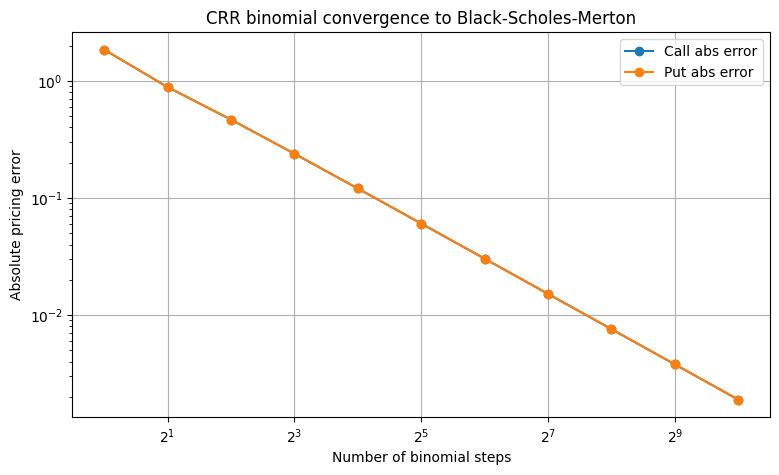

In [10]:
# ============================================================
# Binomial convergence bridge: CRR prices versus Black-Scholes-Merton
# ============================================================

def crr_binomial_price(
    S: float,
    K: float,
    tau: float,
    r: float,
    q: float,
    sigma: float,
    n_steps: int,
    option_type: str = "call",
) -> float:
    """
    Cox-Ross-Rubinstein European option price with continuous dividend yield.

    This is used only as a bridge back to Notebook 01:

        binomial replication -> continuous-time Black-Scholes limit

    Parameters
    ----------
    option_type:
        'call' or 'put'
    """
    if option_type not in {"call", "put"}:
        raise ValueError("option_type must be 'call' or 'put'.")

    if n_steps < 1:
        raise ValueError("n_steps must be at least 1.")

    S_arr, K_arr, tau_arr, r_arr, q_arr, sigma_arr = validate_bsm_inputs(
        S, K, tau, r, q, sigma
    )

    S0 = float(S_arr.reshape(-1)[0])
    K0 = float(K_arr.reshape(-1)[0])
    tau0 = float(tau_arr.reshape(-1)[0])
    r0 = float(r_arr.reshape(-1)[0])
    q0 = float(q_arr.reshape(-1)[0])
    sigma0 = float(sigma_arr.reshape(-1)[0])

    if tau0 == 0.0:
        if option_type == "call":
            return float(intrinsic_call_value(S0, K0))
        return float(intrinsic_put_value(S0, K0))

    if sigma0 == 0.0:
        if option_type == "call":
            return float(deterministic_call_value(S0, K0, tau0, r0, q0))
        return float(deterministic_put_value(S0, K0, tau0, r0, q0))

    dt = tau0 / n_steps
    sqrt_dt = math.sqrt(dt)

    u = math.exp(sigma0 * sqrt_dt)
    d = 1.0 / u

    growth = math.exp((r0 - q0) * dt)
    discount = math.exp(-r0 * dt)

    p = (growth - d) / (u - d)

    if not (0.0 <= p <= 1.0):
        raise ValueError(
            "CRR risk-neutral probability is outside [0, 1]. "
            "The chosen step size is not admissible for these parameters."
        )

    j = np.arange(n_steps + 1)
    terminal_stock = S0 * (u ** j) * (d ** (n_steps - j))

    if option_type == "call":
        option_values = np.maximum(terminal_stock - K0, 0.0)
    else:
        option_values = np.maximum(K0 - terminal_stock, 0.0)

    for _ in range(n_steps):
        option_values = discount * (
            p * option_values[1:] + (1.0 - p) * option_values[:-1]
        )

    return float(option_values[0])


def build_crr_convergence_table(
    base: BlackScholesInputs,
    n_steps_values: list[int] | None = None,
) -> pd.DataFrame:
    """
    Compare CRR binomial prices against Black-Scholes-Merton closed-form prices.
    """
    if n_steps_values is None:
        n_steps_values = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]

    bs_call = bsm_call_price(base.S, base.K, base.tau, base.r, base.q, base.sigma)
    bs_put = bsm_put_price(base.S, base.K, base.tau, base.r, base.q, base.sigma)

    rows = []

    for n_steps in n_steps_values:
        crr_call = crr_binomial_price(
            base.S,
            base.K,
            base.tau,
            base.r,
            base.q,
            base.sigma,
            n_steps=n_steps,
            option_type="call",
        )

        crr_put = crr_binomial_price(
            base.S,
            base.K,
            base.tau,
            base.r,
            base.q,
            base.sigma,
            n_steps=n_steps,
            option_type="put",
        )

        rows.append(
            {
                "n_steps": n_steps,
                "bs_call": bs_call,
                "crr_call": crr_call,
                "call_abs_error": abs(crr_call - bs_call),
                "bs_put": bs_put,
                "crr_put": crr_put,
                "put_abs_error": abs(crr_put - bs_put),
            }
        )

    return pd.DataFrame(rows)


# -----------------------------
# Run convergence check
# -----------------------------

crr_convergence = build_crr_convergence_table(BASE)

final_call_error = float(crr_convergence["call_abs_error"].iloc[-1])
final_put_error = float(crr_convergence["put_abs_error"].iloc[-1])

initial_call_error = float(crr_convergence["call_abs_error"].iloc[0])
initial_put_error = float(crr_convergence["put_abs_error"].iloc[0])

CRR_FINAL_ERROR_TOL = 2e-2

crr_convergence_audit = pd.DataFrame(
    [
        {
            "check": "crr_call_final_error_within_tolerance",
            "metric": final_call_error,
            "threshold": CRR_FINAL_ERROR_TOL,
            "passed": final_call_error <= CRR_FINAL_ERROR_TOL,
        },
        {
            "check": "crr_put_final_error_within_tolerance",
            "metric": final_put_error,
            "threshold": CRR_FINAL_ERROR_TOL,
            "passed": final_put_error <= CRR_FINAL_ERROR_TOL,
        },
        {
            "check": "crr_call_error_improves_from_n1",
            "metric": final_call_error / initial_call_error,
            "threshold": 1.0,
            "passed": final_call_error < initial_call_error,
        },
        {
            "check": "crr_put_error_improves_from_n1",
            "metric": final_put_error / initial_put_error,
            "threshold": 1.0,
            "passed": final_put_error < initial_put_error,
        },
    ]
)

print("CRR binomial convergence audit:")
display(crr_convergence_audit)

print("CRR convergence table:")
display(crr_convergence)

fig, ax = plt.subplots()
ax.plot(crr_convergence["n_steps"], crr_convergence["call_abs_error"], marker="o", label="Call abs error")
ax.plot(crr_convergence["n_steps"], crr_convergence["put_abs_error"], marker="o", label="Put abs error")
ax.set_xscale("log", base=2)
ax.set_yscale("log")
ax.set_title("CRR binomial convergence to Black-Scholes-Merton")
ax.set_xlabel("Number of binomial steps")
ax.set_ylabel("Absolute pricing error")
ax.legend()
plt.show()

if not bool(crr_convergence_audit["passed"].all()):
    raise AssertionError("CRR-to-Black-Scholes convergence audit failed.")

In [11]:
# ============================================================
# Final notebook audit
# ============================================================

def normalize_audit_row(
    section: str,
    check: str,
    metric: float,
    threshold: float,
    passed: bool,
) -> dict[str, Any]:
    """
    Standardized final audit row.
    """
    return {
        "section": section,
        "check": check,
        "metric": float(metric),
        "threshold": float(threshold),
        "passed": bool(passed),
    }


final_audit_rows: list[dict[str, Any]] = []


# -----------------------------
# Baseline pricing sanity
# -----------------------------

baseline_prices_finite = bool(
    np.isfinite(base_call)
    and np.isfinite(base_put)
    and np.isfinite(base_d1)
    and np.isfinite(base_d2)
)

baseline_prices_nonnegative = bool(base_call >= -BOUNDS_TOL and base_put >= -BOUNDS_TOL)

final_audit_rows.append(
    normalize_audit_row(
        section="baseline_pricing",
        check="baseline_prices_and_d_values_finite",
        metric=0.0 if baseline_prices_finite else 1.0,
        threshold=0.0,
        passed=baseline_prices_finite,
    )
)

final_audit_rows.append(
    normalize_audit_row(
        section="baseline_pricing",
        check="baseline_prices_nonnegative",
        metric=0.0 if baseline_prices_nonnegative else 1.0,
        threshold=0.0,
        passed=baseline_prices_nonnegative,
    )
)


# -----------------------------
# Put-call parity and bounds
# -----------------------------

for _, row in bound_audit_summary.iterrows():
    final_audit_rows.append(
        normalize_audit_row(
            section="parity_and_bounds",
            check=str(row["check"]),
            metric=float(row["max_violation"]),
            threshold=float(row["threshold"]),
            passed=bool(row["passed"]),
        )
    )


# -----------------------------
# Greek finite-difference checks
# -----------------------------

for _, row in greek_fd_audit.iterrows():
    final_audit_rows.append(
        normalize_audit_row(
            section="finite_difference_greeks",
            check=f"{row['option_type']}_{row['greek']}",
            metric=float(row["abs_error"]),
            threshold=float(row["abs_tol"]),
            passed=bool(row["passed"]),
        )
    )


# -----------------------------
# PDE residual checks
# -----------------------------

for _, row in pde_audit_summary.iterrows():
    final_audit_rows.append(
        normalize_audit_row(
            section="pde_residual",
            check=str(row["check"]),
            metric=float(row["max_abs_residual"]),
            threshold=float(row["threshold"]),
            passed=bool(row["passed"]),
        )
    )


# -----------------------------
# Strike behavior
# -----------------------------

for _, row in strike_behavior_audit.iterrows():
    final_audit_rows.append(
        normalize_audit_row(
            section="strike_behavior",
            check=str(row["check"]),
            metric=float(row["violation_count"]),
            threshold=0.0,
            passed=bool(row["passed"]),
        )
    )


# -----------------------------
# Volatility and maturity behavior
# -----------------------------

for _, row in volatility_behavior_audit.iterrows():
    final_audit_rows.append(
        normalize_audit_row(
            section="volatility_and_maturity_behavior",
            check=str(row["check"]),
            metric=float(row["violation_count"]),
            threshold=0.0,
            passed=bool(row["passed"]),
        )
    )


# -----------------------------
# Limiting and edge cases
# -----------------------------

for _, row in edge_case_audit_summary.iterrows():
    final_audit_rows.append(
        normalize_audit_row(
            section="limiting_and_edge_cases",
            check=str(row["check"]),
            metric=float(row["metric"]),
            threshold=float(row["threshold"]),
            passed=bool(row["passed"]),
        )
    )


# -----------------------------
# CRR convergence bridge
# -----------------------------

for _, row in crr_convergence_audit.iterrows():
    final_audit_rows.append(
        normalize_audit_row(
            section="crr_convergence",
            check=str(row["check"]),
            metric=float(row["metric"]),
            threshold=float(row["threshold"]),
            passed=bool(row["passed"]),
        )
    )


# -----------------------------
# Final status
# -----------------------------

notebook_04_final_audit = pd.DataFrame(final_audit_rows)

notebook_04_section_summary = (
    notebook_04_final_audit
    .groupby("section", as_index=False)
    .agg(
        checks=("check", "count"),
        passed_checks=("passed", "sum"),
        failed_checks=("passed", lambda x: int((~x).sum())),
        section_passed=("passed", "all"),
    )
)

NOTEBOOK_04_PASSED = bool(notebook_04_final_audit["passed"].all())

print("Notebook 04 section-level audit summary:")
display(notebook_04_section_summary)

print("Notebook 04 final audit table:")
display(notebook_04_final_audit)

print(f"NOTEBOOK_04_PASSED = {NOTEBOOK_04_PASSED}")

if not NOTEBOOK_04_PASSED:
    failed_checks = notebook_04_final_audit.loc[
        ~notebook_04_final_audit["passed"]
    ].copy()

    print("Failed checks:")
    display(failed_checks)

    raise AssertionError("Notebook 04 final audit failed.")

Notebook 04 section-level audit summary:


,section,checks,passed_checks,failed_checks,section_passed
0,baseline_pricing,2,2,0,True
1,crr_convergence,4,4,0,True
2,finite_difference_greeks,10,10,0,True
3,limiting_and_edge_cases,5,5,0,True
4,parity_and_bounds,5,5,0,True
5,pde_residual,2,2,0,True
6,strike_behavior,6,6,0,True
7,volatility_and_maturity_behavior,5,5,0,True


Notebook 04 final audit table:


,section,check,metric,threshold,passed
0,baseline_pricing,baseline_prices_and_d_values_finite,0.0000000000,0.0000000000,True
1,baseline_pricing,baseline_prices_nonnegative,0.0000000000,0.0000000000,True
2,parity_and_bounds,put_call_parity,0.0000000000,0.0000000001,True
3,parity_and_bounds,call_lower_bound,0.0000000000,0.0000000001,True
4,parity_and_bounds,call_upper_bound,0.0000000000,0.0000000001,True
5,parity_and_bounds,put_lower_bound,0.0000000000,0.0000000001,True
6,parity_and_bounds,put_upper_bound,0.0000000000,0.0000000001,True
7,finite_difference_greeks,call_delta,0.0000000001,0.0000100000,True
8,finite_difference_greeks,call_gamma,0.0000000223,0.0001000000,True
9,finite_difference_greeks,call_vega,0.0000000008,0.0001000000,True


NOTEBOOK_04_PASSED = True


## 10. Final interpretation and handoff

Notebook 04 passed its final audit.

The implemented Black-Scholes-Merton benchmark is now internally consistent under the continuous-dividend setup. The notebook verified pricing identities, no-arbitrage bounds, Greek formulas, finite-difference sensitivities, PDE consistency, limiting cases, and CRR binomial convergence.

This does not make Black-Scholes empirically realistic. It only means the benchmark layer is mathematically and numerically stable enough to use as a reference model in the next notebook.

---

## What was verified

The notebook verified the following:

1. Baseline call and put prices are finite and nonnegative.
2. Put-call parity holds under continuous dividend yield.
3. Call and put prices obey basic no-arbitrage bounds.
4. Analytic Greeks match finite-difference estimates.
5. Call and put formulas satisfy the Black-Scholes-Merton PDE numerically.
6. Strike behavior is economically sensible.
7. Prices are nondecreasing in volatility on the tested grid.
8. Near-expiry prices converge toward intrinsic value.
9. Zero-volatility prices match deterministic discounted payoff values.
10. CRR binomial prices converge toward the Black-Scholes-Merton closed-form benchmark.

---

## Claims allowed

This notebook supports the following claims:

1. European Black-Scholes-Merton call and put prices were implemented with continuous dividend yield.
2. The implementation satisfies continuous-dividend put-call parity on the tested grid.
3. The implementation obeys basic European option no-arbitrage bounds on the tested grid.
4. The analytic Greeks are consistent with finite-difference approximations at the baseline parameter set.
5. The implemented prices and Greeks satisfy the Black-Scholes-Merton PDE numerically.
6. The implementation behaves correctly in tested limiting cases.
7. The implementation can be used as a benchmark for later Monte Carlo and implied-volatility work.

---

## Claims not allowed

This notebook does not support the following claims:

1. Real option prices follow Black-Scholes-Merton.
2. SPY options are accurately priced by Black-Scholes-Merton.
3. Constant volatility is empirically realistic.
4. The model explains volatility smiles or skews.
5. The model has been calibrated to market data.
6. The Greeks are reliable under real market frictions.
7. Continuous hedging is practically achievable.
8. This notebook validates a trading strategy.
9. This notebook justifies moving directly to Heston, Bates, or volatility-surface calibration.

---

## Handoff to Notebook 05

The next notebook should be named:

`05_risk_neutral_pricing_monte_carlo.ipynb`

Notebook 05 should use the Black-Scholes-Merton prices from this notebook as benchmark values.

The central question for Notebook 05 should be:

> Can risk-neutral Monte Carlo recover the Black-Scholes-Merton call and put prices within simulation error?

The next notebook should not introduce market data yet.

Its job should be to test whether simulation under the risk-neutral measure produces discounted payoff estimates consistent with the closed-form Black-Scholes-Merton benchmark.

The intended sequence is:

1. start from the closed-form Black-Scholes-Merton benchmark price
2. simulate risk-neutral GBM terminal prices
3. compute discounted option payoffs
4. estimate Monte Carlo prices and confidence intervals
5. compare the simulation estimates against the closed-form benchmark

Notebook 04 is now the closed-form benchmark layer. Notebook 05 should test whether the same pricing logic can be recovered through simulation.